$ conda activate statKi
$ conda deactivate

# Vorbereitungen

In [1]:
import pandas as pd
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, zscore, median_abs_deviation, f_oneway, kruskal, gaussian_kde, chi2, norm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests
import numpy as np
import re 
import seaborn as sns
import math
from math import erf, sqrt
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import PercentFormatter
import scikit_posthocs as sp
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer
from itertools import combinations, product
import patchworklib as pw
from matplotlib.gridspec import GridSpec
import string
import pylab 
from openpyxl import load_workbook
from openpyxl.styles import PatternFill
from openpyxl.utils import get_column_letter
from textwrap import fill

import warnings
warnings.filterwarnings('ignore')
from scipy.stats import f as f_dist
from scipy.stats import t as t_dist
from typing import Optional
from matplotlib.colors import TwoSlopeNorm




from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson



<Figure size 100x100 with 0 Axes>

# Load dataset

In [ ]:

subdatset_df = pd.read_excel("./subdatset_EC50_df_checked.xlsx")

# Subdataframes

In [6]:
CP_df = subdatset_df[subdatset_df.pubchem_cid == 104895.0].copy() 
Rimonabant_df = subdatset_df[subdatset_df.pubchem_cid == 104850.0].copy() 
WIN_df = subdatset_df[subdatset_df.pubchem_cid == 5311501.0].copy() 
CHEMBL4450922_df = subdatset_df[subdatset_df.pubchem_cid == 4402318.0].copy()
THC9_df = subdatset_df[subdatset_df.pubchem_cid == 16078.0].copy()
CHEMBL4467516_df = subdatset_df[subdatset_df.pubchem_cid == 155532408.0].copy()
CHEMBL4519310_df = subdatset_df[subdatset_df.pubchem_cid == 155541870.0].copy()
CHEMBL4549068_df = subdatset_df[subdatset_df.pubchem_cid == 155491029.0].copy()
JWH018_df = subdatset_df[subdatset_df.pubchem_cid == 10382701.0].copy()
ZCZ011_df = subdatset_df[subdatset_df.pubchem_cid == 71819307.0].copy()

## Figures for publication (general)

### Histograms

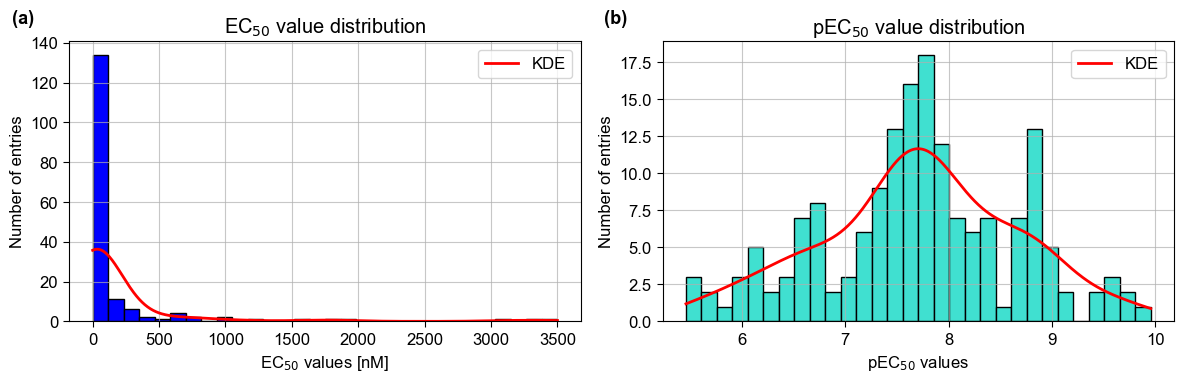

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Plot 1: EC50 values
data_EC50 = subdatset_df["value"]
counts_EC50, bins_EC50, _ = axes[0].hist(data_EC50, bins=30, color='Blue', edgecolor='black')
axes[0].set_title('EC$_{50}$ value distribution')
axes[0].set_xlabel('EC$_{50}$ values [nM]')
axes[0].set_ylabel('Number of entries')

# KDE passend zur Histogramm-Skala
kde_EC50 = gaussian_kde(data_EC50)
x_EC50 = np.linspace(data_EC50.min(), data_EC50.max(), 500)
bin_width_EC50 = bins_EC50[1] - bins_EC50[0]
axes[0].plot(x_EC50, kde_EC50(x_EC50) * len(data_EC50) * bin_width_EC50, color="red", lw=2, label="KDE")
axes[0].legend(loc="upper right")

# Plot 2: pEC50 values
data_pEC50 = subdatset_df["value_pEC50"]
counts_pEC50, bins_pEC50, _ = axes[1].hist(data_pEC50, bins=30, color='Turquoise', edgecolor='black')
axes[1].set_title('pEC$_{50}$ value distribution')
axes[1].set_xlabel('pEC$_{50}$ values')
axes[1].set_ylabel('Number of entries')

# KDE passend zur Histogramm-Skala
kde_pEC50 = gaussian_kde(data_pEC50)
x_pEC50 = np.linspace(data_pEC50.min(), data_pEC50.max(), 500)
bin_width_pEC50 = bins_pEC50[1] - bins_pEC50[0]
axes[1].plot(x_pEC50, kde_pEC50(x_pEC50) * len(data_pEC50) * bin_width_pEC50, color="red", lw=2, label="KDE")
axes[1].legend(loc="upper right")

#loop for the background grid
for ax in axes:
    ax.grid(True, linestyle="-", alpha=0.7)


# Adjust positions relative to axes (negative y puts it slightly above the plot)
axes[0].text(-0.07, 1.05, "(a)", transform=axes[0].transAxes,
             fontsize=13, fontweight="bold", va="bottom", ha="right")
axes[1].text(-0.07, 1.05, "(b)", transform=axes[1].transAxes,
             fontsize=13, fontweight="bold", va="bottom", ha="right")
# Layout anpassen
plt.tight_layout()

# Save & show
plt.savefig("Histogram_EC50_and_pEC50_with_KDE.png", dpi=300)
plt.show()

### QQ plot

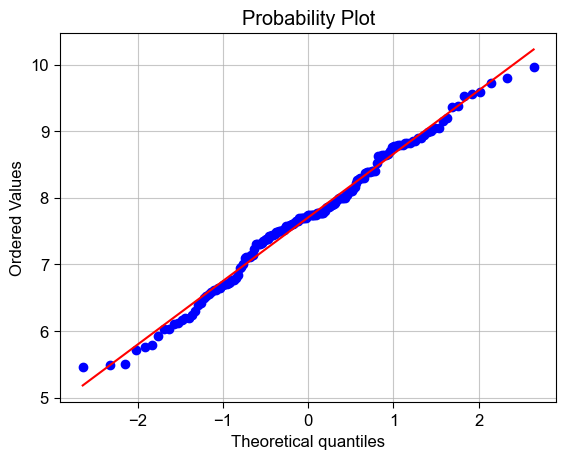

In [5]:
stats.probplot(subdatset_df["value_pEC50"], dist="norm", plot=pylab)

ax = plt.gca()
ax.grid(True, linestyle='-', alpha=0.7)
ax.set_axisbelow(True)
plt.savefig("QQ_plot_dataset_pEC50.png", dpi=300)
pylab.show()

# LMM
##  LMM with Multiple Imputation

In [7]:
# ============================================================
# Generic MI-LMM workflow for CB1 pEC50
# - Response: value_pEC50
# - Random effect: random intercept for pubchem_cid
# - Multiple imputation for numeric + categorical covariates
# - Designed for running separate models to avoid multicollinearity
# ============================================================


warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ------------------------------------------------------------
# 1) HELPERS
# ------------------------------------------------------------
def make_safe(name: str) -> str:
    safe = re.sub(r"[^0-9a-zA-Z_]", "_", str(name))
    if re.match(r"^[0-9]", safe):
        safe = "v_" + safe
    return re.sub(r"_+", "_", safe).strip("_")

def norm_label(x: str) -> str:
    return re.sub(r"[^0-9A-Za-z]+", "", str(x)).lower()

def match_reference_level(observed_values, desired_label):
    for v in observed_values:
        if norm_label(v) == norm_label(desired_label):
            return v
    return desired_label

def rubin_pool_scalar(estimates, ses):
    q = np.asarray(estimates, dtype=float)
    u = np.asarray(ses, dtype=float) ** 2
    m = len(q)

    qbar = q.mean()
    ubar = u.mean()
    b = q.var(ddof=1) if m > 1 else 0.0
    t = ubar + (1 + 1/m) * b
    se = np.sqrt(t)

    z = qbar / se if se > 0 else np.nan
    p = 2 * norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return qbar, se, z, p, ubar, b

def pool_fixed_effects(fe_params_list, fe_cov_list):
    coef_names = fe_params_list[0].index.tolist()
    rows = []

    for name in coef_names:
        ests = [p[name] for p in fe_params_list]
        ses = [np.sqrt(c.loc[name, name]) for c in fe_cov_list]

        qbar, se, z, p, ubar, b = rubin_pool_scalar(ests, ses)

        rows.append({
            "term": name,
            "estimate": qbar,
            "std_error": se,
            "z_approx": z,
            "p_value_approx": p,
            "ci_low_95": qbar - 1.96 * se,
            "ci_high_95": qbar + 1.96 * se,
            "within_var": ubar,
            "between_var": b
        })

    return pd.DataFrame(rows)

def extract_variance_summary(res_list):
    rows = []
    for i, res in enumerate(res_list, start=1):
        group_var = float(res.cov_re.iloc[0, 0]) if hasattr(res, "cov_re") else np.nan
        residual_var = float(res.scale)
        icc = group_var / (group_var + residual_var) if (group_var + residual_var) > 0 else np.nan

        rows.append({
            "imp": i,
            "group_var": group_var,
            "residual_var": residual_var,
            "ICC": icc
        })
    return pd.DataFrame(rows)

def mi_diagnostics(imputer, imp_df, num_cols, cat_cols, cat_dummy_cols, base_df, n_draws=5):
    diagnostics = []
    draws = []

    for _ in range(n_draws):
        arr = imputer.transform(imp_df)
        draws.append(pd.DataFrame(arr, columns=imp_df.columns, index=imp_df.index))

    for c in num_cols:
        miss = base_df[c].isna()
        n_missing = int(miss.sum())

        if n_missing == 0:
            diagnostics.append({
                "variable": c,
                "type": "numeric",
                "n_missing": 0,
                "metric": "no missing values",
                "value": np.nan
            })
            continue

        mat = np.column_stack([d.loc[miss, c].to_numpy() for d in draws])
        mean_sd = np.std(mat, axis=1, ddof=1).mean() if mat.shape[1] > 1 else 0.0

        diagnostics.append({
            "variable": c,
            "type": "numeric",
            "n_missing": n_missing,
            "metric": "mean SD across imputations",
            "value": float(mean_sd)
        })

    for c in cat_cols:
        miss = base_df[c].isna()
        n_missing = int(miss.sum())

        if n_missing == 0:
            diagnostics.append({
                "variable": c,
                "type": "categorical",
                "n_missing": 0,
                "metric": "no missing values",
                "value": np.nan
            })
            continue

        cols = cat_dummy_cols[c]
        if len(cols) == 0:
            diagnostics.append({
                "variable": c,
                "type": "categorical",
                "n_missing": n_missing,
                "metric": "no dummy columns",
                "value": np.nan
            })
            continue

        cat_draws = []
        for d in draws:
            block = d.loc[miss, cols].copy()
            chosen = block.idxmax(axis=1).str.replace(f"{c}_", "", regex=False)
            cat_draws.append(chosen)

        cat_draws_df = pd.concat(cat_draws, axis=1)
        n_unique = cat_draws_df.nunique(axis=1)
        instability = (n_unique > 1).mean()

        diagnostics.append({
            "variable": c,
            "type": "categorical",
            "n_missing": n_missing,
            "metric": "share rows changing category across imputations",
            "value": float(instability)
        })

    return pd.DataFrame(diagnostics)

def create_one_imputed_dataset(base_df, imp_df, imputer, cats, nums, cat_dummy_cols, y_col, group_col):
    arr = imputer.transform(imp_df)
    imp_complete = pd.DataFrame(arr, columns=imp_df.columns, index=imp_df.index)

    out = base_df[[y_col, group_col] + cats + nums].copy()

    for c in nums:
        miss = out[c].isna()
        out.loc[miss, c] = imp_complete.loc[miss, c]

    for c in cats:
        miss = out[c].isna()
        cols = cat_dummy_cols[c]
        if len(cols) == 0:
            continue

        chosen = imp_complete.loc[miss, cols].idxmax(axis=1).str.replace(f"{c}_", "", regex=False)
        out.loc[miss, c] = chosen.values
        out[c] = out[c].where(out[c].isna(), out[c].astype(str).str.strip())
        out[c] = out[c].astype("category")

    out[group_col] = out[group_col].where(out[group_col].isna(), out[group_col].astype(str).str.strip())
    out[group_col] = out[group_col].astype("category")

    return out

def fit_mixedlm_safe(formula, data, group_col, categorical_cols, reml=True):
    data = data.copy()

    for c in categorical_cols:
        data[c] = data[c].astype("category")
    data[group_col] = data[group_col].astype("category")

    model = smf.mixedlm(formula, data=data, groups=data[group_col])

    errors = []
    for method in ["lbfgs", "powell", "nm"]:
        try:
            res = model.fit(reml=reml, method=method, disp=False)
            return res
        except Exception as e:
            errors.append((method, str(e)))

    raise RuntimeError(f"MixedLM failed for all optimizers: {errors}")

In [8]:
# ============================================================
# 2) MAIN FUNCTION TO RUN ONE pEC50 MI-LMM
# ============================================================
def run_pEC50_mi_lmm(
    df_raw,
    model_name,
    categorical_vars,
    numeric_vars_raw,
    y_var="value_pEC50",
    group_var="pubchem_cid",
    reference_levels=None,
    mi_m=20,
    mi_max_iter=30,
    mi_random_seed=42,
    use_reml_final=True,
    fit_null_model=True,
    log10_time=True,
    export_excel=True
):
    if reference_levels is None:
        reference_levels = {}

    needed_cols = [y_var, group_var] + categorical_vars + numeric_vars_raw
    missing_needed = [c for c in needed_cols if c not in df_raw.columns]
    if missing_needed:
        raise ValueError(f"Missing required columns: {missing_needed}")

    df = df_raw[needed_cols].copy()
    df = df.dropna(subset=[y_var, group_var]).copy()

    rename_cols = {c: make_safe(c) for c in df.columns}
    df = df.rename(columns=rename_cols)

    Y = make_safe(y_var)
    GROUP = make_safe(group_var)

    CATS = [make_safe(c) for c in categorical_vars]
    NUMS_RAW_SAFE = [make_safe(c) for c in numeric_vars_raw]

    cat_map = dict(zip(categorical_vars, CATS))
    num_map = dict(zip(numeric_vars_raw, NUMS_RAW_SAFE))

    for c in CATS:
        df[c] = df[c].astype("object")
        df[c] = df[c].where(df[c].isna(), df[c].astype(str).str.strip())

    df[GROUP] = df[GROUP].astype("object")
    df[GROUP] = df[GROUP].where(df[GROUP].isna(), df[GROUP].astype(str).str.strip())

    for c in NUMS_RAW_SAFE:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # optional log10 transform for incubation time
    if log10_time and "incubation_time" in numeric_vars_raw:
        raw_time = make_safe("incubation_time")
        new_time = "log10_incubation_time"
        df[new_time] = df[raw_time].where(df[raw_time] > 0, np.nan)
        df[new_time] = np.log10(df[new_time])
        NUMS = [new_time if x == raw_time else x for x in NUMS_RAW_SAFE]
    else:
        NUMS = NUMS_RAW_SAFE

    observed_reference_levels = {}
    for orig_name, safe_name in cat_map.items():
        observed = df[safe_name].dropna().astype(str).unique().tolist()
        desired = reference_levels.get(orig_name, None)
        if desired is None:
            matched = observed[0] if len(observed) > 0 else None
        else:
            matched = match_reference_level(observed, desired)
        observed_reference_levels[safe_name] = matched

    print(f"\n===== {model_name} =====")
    print("Matched reference levels:")
    for k, v in observed_reference_levels.items():
        print(f"  {k}: {v}")

    base_df = df[[Y, GROUP] + CATS + NUMS].copy()

    missing_masks_numeric = {c: base_df[c].isna().copy() for c in NUMS}
    missing_masks_categorical = {c: base_df[c].isna().copy() for c in CATS}

    cat_dummy_cols = {}
    for c in CATS:
        dummies = pd.get_dummies(base_df[c], prefix=c, dtype=float)
        miss = base_df[c].isna()
        if dummies.shape[1] > 0:
            dummies.loc[miss, :] = np.nan
        cat_dummy_cols[c] = dummies.columns.tolist()
        base_df = pd.concat([base_df, dummies], axis=1)

    group_dummies = pd.get_dummies(base_df[GROUP].astype(str), prefix="grp", dtype=float)
    base_df = pd.concat([base_df, group_dummies], axis=1)

    cat_dummy_all = [col for cols in cat_dummy_cols.values() for col in cols]
    aux_cols = [Y] + group_dummies.columns.tolist()
    imputation_cols = NUMS + cat_dummy_all + aux_cols
    imp_df = base_df[imputation_cols].copy()

    print("\nMissing values before MI:")
    for c in NUMS:
        print(f"  numeric {c}: {int(missing_masks_numeric[c].sum())}")
    for c in CATS:
        print(f"  categorical {c}: {int(missing_masks_categorical[c].sum())}")

    imputer = IterativeImputer(
        max_iter=mi_max_iter,
        sample_posterior=True,
        random_state=mi_random_seed,
        skip_complete=False
    )
    imputer.fit(imp_df)

    diag_df = mi_diagnostics(
        imputer=imputer,
        imp_df=imp_df,
        num_cols=NUMS,
        cat_cols=CATS,
        cat_dummy_cols=cat_dummy_cols,
        base_df=base_df,
        n_draws=5
    )

    print("\nMI diagnostics per variable:")
    print(diag_df.to_string(index=False))

    # model formula
    fixed_terms = []
    for c in CATS:
        ref = observed_reference_levels[c]
        fixed_terms.append(f"C({c}, Treatment(reference={repr(ref)}))")
    for n in NUMS:
        fixed_terms.append(n)

    formula_fixed = f"{Y} ~ " + " + ".join(fixed_terms)
    formula_null = f"{Y} ~ 1"

    print("\nModel formulas:")
    print("NULL :", formula_null, f"+ (1 | {GROUP})")
    print("FULL :", formula_fixed, f"+ (1 | {GROUP})")

    full_results = []
    null_results = []

    for m_idx in range(mi_m):
        df_imp = create_one_imputed_dataset(
            base_df=base_df,
            imp_df=imp_df,
            imputer=imputer,
            cats=CATS,
            nums=NUMS,
            cat_dummy_cols=cat_dummy_cols,
            y_col=Y,
            group_col=GROUP
        )

        res_full = fit_mixedlm_safe(
            formula=formula_fixed,
            data=df_imp,
            group_col=GROUP,
            categorical_cols=CATS,
            reml=use_reml_final
        )
        full_results.append(res_full)

        if fit_null_model:
            res_null = fit_mixedlm_safe(
                formula=formula_null,
                data=df_imp,
                group_col=GROUP,
                categorical_cols=CATS,
                reml=use_reml_final
            )
            null_results.append(res_null)

    print(f"\nSuccessfully fitted {len(full_results)} imputed full models.")

    fe_params_list = []
    fe_cov_list = []

    for res in full_results:
        fe_names = res.fe_params.index.tolist()
        fe_params = res.fe_params.copy()
        fe_cov = res.cov_params().loc[fe_names, fe_names].copy()
        fe_params_list.append(fe_params)
        fe_cov_list.append(fe_cov)

    pooled_fixed = pool_fixed_effects(fe_params_list, fe_cov_list)

    print("\nPooled fixed effects (Rubin; large-sample normal approximation):")
    print(pooled_fixed.to_string(index=False))

    full_var_df = extract_variance_summary(full_results)
    print("\nVariance summary across imputations (full model):")
    print(full_var_df[["group_var", "residual_var", "ICC"]].agg(["mean", "median", "min", "max"]).to_string())

    if fit_null_model and len(null_results) > 0:
        null_var_df = extract_variance_summary(null_results)
        print("\nVariance summary across imputations (null model):")
        print(null_var_df[["group_var", "residual_var", "ICC"]].agg(["mean", "median", "min", "max"]).to_string())
    else:
        null_var_df = None

    print("\nExample full-model summary from imputation 1:")
    print(full_results[0].summary())

    if export_excel:
        output_file = f"{model_name}_MI_LMM_results.xlsx"
        with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
            pooled_fixed.to_excel(writer, sheet_name="pooled_fixed_effects", index=False)
            diag_df.to_excel(writer, sheet_name="mi_diagnostics", index=False)
            full_var_df.to_excel(writer, sheet_name="full_model_variance", index=False)

            if null_var_df is not None:
                null_var_df.to_excel(writer, sheet_name="null_model_variance", index=False)

            fe_names = full_results[0].fe_params.index.tolist()
            imp1_coef_df = pd.DataFrame({
                "term": fe_names,
                "estimate": full_results[0].fe_params.values,
                "std_error": full_results[0].bse_fe.values,
                "z_value": full_results[0].tvalues[fe_names].values,
                "p_value": full_results[0].pvalues[fe_names].values,
                "ci_low_95": full_results[0].conf_int().loc[fe_names, 0].values,
                "ci_high_95": full_results[0].conf_int().loc[fe_names, 1].values,
            })
            imp1_coef_df.to_excel(writer, sheet_name="imputation1_fixed_effects", index=False)

            imp1_var_df = pd.DataFrame({
                "metric": ["group_var", "residual_var", "ICC"],
                "value": [
                    float(full_results[0].cov_re.iloc[0, 0]),
                    float(full_results[0].scale),
                    float(full_results[0].cov_re.iloc[0, 0]) / (
                        float(full_results[0].cov_re.iloc[0, 0]) + float(full_results[0].scale)
                    )
                ]
            })
            imp1_var_df.to_excel(writer, sheet_name="imputation1_variance", index=False)

        print(f"\nExcel file saved: {output_file}")

    return {
        "model_name": model_name,
        "pooled_fixed": pooled_fixed,
        "diag_df": diag_df,
        "full_var_df": full_var_df,
        "null_var_df": null_var_df,
        "full_results": full_results,
        "null_results": null_results,
        "observed_reference_levels": observed_reference_levels,
        "formula_fixed": formula_fixed,
        "formula_null": formula_null
    }

In [9]:
# ============================================================
# MODEL A: pEC50 ~ receptor_species + assay_readout_clean + log10_incubation_time + temp
# ============================================================
pEC50_readout_model = run_pEC50_mi_lmm(
    df_raw=subdatset_df.copy(),
    model_name="pEC50_readout_model",
    categorical_vars=[
        "receptor_species",
        "assay_readout_clean"
    ],
    numeric_vars_raw=[
        "incubation_time",
        "temp"
    ],
    y_var="value_pEC50",
    group_var="pubchem_cid",
    reference_levels={
        "receptor_species": "human",
        "assay_readout_clean": "chemiluminescence"
    },
    mi_m=20,
    mi_max_iter=30,
    mi_random_seed=42,
    use_reml_final=True,
    fit_null_model=True,
    log10_time=True,
    export_excel=True
)


===== pEC50_readout_model =====
Matched reference levels:
  receptor_species: human
  assay_readout_clean: chemiluminescence

Missing values before MI:
  numeric log10_incubation_time: 6
  numeric temp: 11
  categorical receptor_species: 5
  categorical assay_readout_clean: 0

MI diagnostics per variable:
             variable        type  n_missing                                          metric    value
log10_incubation_time     numeric          6                      mean SD across imputations 0.499766
                 temp     numeric         11                      mean SD across imputations 4.331787
     receptor_species categorical          5 share rows changing category across imputations 1.000000
  assay_readout_clean categorical          0                               no missing values      NaN

Model formulas:
NULL : value_pEC50 ~ 1 + (1 | pubchem_cid)
FULL : value_pEC50 ~ C(receptor_species, Treatment(reference='human')) + C(assay_readout_clean, Treatment(reference='chemi

In [10]:
# ============================================================
# MODEL B: pEC50 ~ receptor_species + cell_membrane_clean + log10_incubation_time + temp
# ============================================================
pEC50_membrane_model = run_pEC50_mi_lmm(
    df_raw=subdatset_df.copy(),
    model_name="pEC50_membrane_model",
    categorical_vars=[
        "receptor_species",
        "cell_membrane_clean"
    ],
    numeric_vars_raw=[
        "incubation_time",
        "temp"
    ],
    y_var="value_pEC50",
    group_var="pubchem_cid",
    reference_levels={
        "receptor_species": "human",
        "cell_membrane_clean": "cho"
    },
    mi_m=20,
    mi_max_iter=30,
    mi_random_seed=42,
    use_reml_final=True,
    fit_null_model=True,
    log10_time=True,
    export_excel=True
)


===== pEC50_membrane_model =====
Matched reference levels:
  receptor_species: human
  cell_membrane_clean: cho

Missing values before MI:
  numeric log10_incubation_time: 6
  numeric temp: 11
  categorical receptor_species: 5
  categorical cell_membrane_clean: 2

MI diagnostics per variable:
             variable        type  n_missing                                          metric    value
log10_incubation_time     numeric          6                      mean SD across imputations 0.635214
                 temp     numeric         11                      mean SD across imputations 5.620349
     receptor_species categorical          5 share rows changing category across imputations 1.000000
  cell_membrane_clean categorical          2 share rows changing category across imputations 1.000000

Model formulas:
NULL : value_pEC50 ~ 1 + (1 | pubchem_cid)
FULL : value_pEC50 ~ C(receptor_species, Treatment(reference='human')) + C(cell_membrane_clean, Treatment(reference='cho')) + log10_inc

In [11]:
# ============================================================
# MODEL C: pEC50 ~ receptor_species + assay_name_clean + log10_incubation_time + temp
# Sensitivity analysis only
# ============================================================
pEC50_assayname_model = run_pEC50_mi_lmm(
    df_raw=subdatset_df.copy(),
    model_name="pEC50_assayname_model",
    categorical_vars=[
        "receptor_species",
        "assay_name_clean"
    ],
    numeric_vars_raw=[
        "incubation_time",
        "temp"
    ],
    y_var="value_pEC50",
    group_var="pubchem_cid",
    reference_levels={
        "receptor_species": "human",
        "assay_name_clean": "cAMP"
    },
    mi_m=20,
    mi_max_iter=30,
    mi_random_seed=42,
    use_reml_final=True,
    fit_null_model=True,
    log10_time=True,
    export_excel=True
)


===== pEC50_assayname_model =====
Matched reference levels:
  receptor_species: human
  assay_name_clean: cAMP

Missing values before MI:
  numeric log10_incubation_time: 6
  numeric temp: 11
  categorical receptor_species: 5
  categorical assay_name_clean: 0

MI diagnostics per variable:
             variable        type  n_missing                                          metric    value
log10_incubation_time     numeric          6                      mean SD across imputations 0.424318
                 temp     numeric         11                      mean SD across imputations 4.272926
     receptor_species categorical          5 share rows changing category across imputations 1.000000
     assay_name_clean categorical          0                               no missing values      NaN

Model formulas:
NULL : value_pEC50 ~ 1 + (1 | pubchem_cid)
FULL : value_pEC50 ~ C(receptor_species, Treatment(reference='human')) + C(assay_name_clean, Treatment(reference='cAMP')) + log10_incubatio

## LMM without multiple impuation (complete-case-version)

In [12]:
# ============================================================
# Helpers for complete-case LMMs for CB1 pEC50
# ============================================================

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

def make_safe(name: str) -> str:
    safe = re.sub(r"[^0-9a-zA-Z_]", "_", str(name))
    if re.match(r"^[0-9]", safe):
        safe = "v_" + safe
    return re.sub(r"_+", "_", safe).strip("_")

def norm_label(x: str) -> str:
    return re.sub(r"[^0-9A-Za-z]+", "", str(x)).lower()

def match_reference_level(observed_values, desired_label):
    for v in observed_values:
        if norm_label(v) == norm_label(desired_label):
            return v
    return desired_label

def extract_variance_summary_one(res):
    group_var = float(res.cov_re.iloc[0, 0]) if hasattr(res, "cov_re") else np.nan
    residual_var = float(res.scale)
    icc = group_var / (group_var + residual_var) if (group_var + residual_var) > 0 else np.nan
    return {
        "group_var": group_var,
        "residual_var": residual_var,
        "ICC": icc
    }

def fit_mixedlm_safe(formula, data, group_col, categorical_cols, reml=True):
    data = data.copy()

    for c in categorical_cols:
        data[c] = data[c].astype("category")
    data[group_col] = data[group_col].astype("category")

    model = smf.mixedlm(formula, data=data, groups=data[group_col])

    errors = []
    for method in ["lbfgs", "powell", "nm"]:
        try:
            res = model.fit(reml=reml, method=method, disp=False)
            return res
        except Exception as e:
            errors.append((method, str(e)))

    raise RuntimeError(f"MixedLM failed for all optimizers: {errors}")

def run_pEC50_complete_case_lmm(
    df_raw,
    model_name,
    categorical_vars,
    numeric_vars_raw,
    y_var="value_pEC50",
    group_var="pubchem_cid",
    reference_levels=None,
    use_reml_final=True,
    fit_null_model=True,
    log10_time=True,
    export_excel=True
):
    if reference_levels is None:
        reference_levels = {}

    # ------------------------------------------------------------
    # 1) CHECK + SUBSET
    # ------------------------------------------------------------
    needed_cols = [y_var, group_var] + categorical_vars + numeric_vars_raw
    missing_needed = [c for c in needed_cols if c not in df_raw.columns]
    if missing_needed:
        raise ValueError(f"Missing required columns: {missing_needed}")

    df = df_raw[needed_cols].copy()
    df = df.dropna(subset=[y_var, group_var]).copy()

    # ------------------------------------------------------------
    # 2) SAFE NAMES
    # ------------------------------------------------------------
    rename_cols = {c: make_safe(c) for c in df.columns}
    df = df.rename(columns=rename_cols)

    Y = make_safe(y_var)
    GROUP = make_safe(group_var)

    CATS = [make_safe(c) for c in categorical_vars]
    NUMS_RAW_SAFE = [make_safe(c) for c in numeric_vars_raw]

    cat_map = dict(zip(categorical_vars, CATS))

    # ------------------------------------------------------------
    # 3) CLEAN TYPES
    # ------------------------------------------------------------
    for c in CATS:
        df[c] = df[c].astype("object")
        df[c] = df[c].where(df[c].isna(), df[c].astype(str).str.strip())

    df[GROUP] = df[GROUP].astype("object")
    df[GROUP] = df[GROUP].where(df[GROUP].isna(), df[GROUP].astype(str).str.strip())

    for c in NUMS_RAW_SAFE:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # ------------------------------------------------------------
    # 4) OPTIONAL log10 TRANSFORM FOR INCUBATION TIME
    # ------------------------------------------------------------
    if log10_time and "incubation_time" in numeric_vars_raw:
        raw_time = make_safe("incubation_time")
        new_time = "log10_incubation_time"
        df[new_time] = df[raw_time].where(df[raw_time] > 0, np.nan)
        df[new_time] = np.log10(df[new_time])
        NUMS = [new_time if x == raw_time else x for x in NUMS_RAW_SAFE]
    else:
        NUMS = NUMS_RAW_SAFE

    # ------------------------------------------------------------
    # 5) MATCH REFERENCE LEVELS
    # ------------------------------------------------------------
    observed_reference_levels = {}
    for orig_name, safe_name in cat_map.items():
        observed = df[safe_name].dropna().astype(str).unique().tolist()
        desired = reference_levels.get(orig_name, None)
        if desired is None:
            matched = observed[0] if len(observed) > 0 else None
        else:
            matched = match_reference_level(observed, desired)
        observed_reference_levels[safe_name] = matched

    print(f"\n===== {model_name} =====")
    print("Matched reference levels:")
    for k, v in observed_reference_levels.items():
        print(f"  {k}: {v}")

    # ------------------------------------------------------------
    # 6) COMPLETE-CASE FILTER
    # ------------------------------------------------------------
    model_vars = [Y, GROUP] + CATS + NUMS
    df_cc = df[model_vars].copy()

    n_before = len(df_cc)
    df_cc = df_cc.dropna().copy()
    n_after = len(df_cc)
    n_dropped = n_before - n_after

    print("\nComplete-case filtering:")
    print(f"  Rows before complete-case filter: {n_before}")
    print(f"  Rows after complete-case filter : {n_after}")
    print(f"  Rows dropped                    : {n_dropped}")

    print("\nComplete-case group sizes:")
    print(df_cc[GROUP].value_counts().sort_index().to_string())

    # ------------------------------------------------------------
    # 7) FORMULAS
    # ------------------------------------------------------------
    fixed_terms = []
    for c in CATS:
        ref = observed_reference_levels[c]
        fixed_terms.append(f"C({c}, Treatment(reference={repr(ref)}))")
    for n in NUMS:
        fixed_terms.append(n)

    formula_fixed = f"{Y} ~ " + " + ".join(fixed_terms)
    formula_null = f"{Y} ~ 1"

    print("\nModel formulas:")
    print("NULL :", formula_null, f"+ (1 | {GROUP})")
    print("FULL :", formula_fixed, f"+ (1 | {GROUP})")

    # ------------------------------------------------------------
    # 8) FIT MODELS
    # ------------------------------------------------------------
    res_full_cc = fit_mixedlm_safe(
        formula=formula_fixed,
        data=df_cc,
        group_col=GROUP,
        categorical_cols=CATS,
        reml=use_reml_final
    )

    if fit_null_model:
        res_null_cc = fit_mixedlm_safe(
            formula=formula_null,
            data=df_cc,
            group_col=GROUP,
            categorical_cols=CATS,
            reml=use_reml_final
        )
    else:
        res_null_cc = None

    print("\nComplete-case full model fitted successfully.")
    if fit_null_model:
        print("Complete-case null model fitted successfully.")

    # ------------------------------------------------------------
    # 9) FIXED EFFECTS TABLE
    # ------------------------------------------------------------
    full_summary_table = pd.DataFrame({
        "term": res_full_cc.fe_params.index,
        "estimate": res_full_cc.fe_params.values,
        "std_error": res_full_cc.bse_fe.values,
        "z_value": res_full_cc.fe_params.values / res_full_cc.bse_fe.values,
        "p_value": res_full_cc.pvalues.loc[res_full_cc.fe_params.index].values,
        "ci_low_95": res_full_cc.conf_int().loc[res_full_cc.fe_params.index, 0].values,
        "ci_high_95": res_full_cc.conf_int().loc[res_full_cc.fe_params.index, 1].values
    })

    print("\nComplete-case fixed effects:")
    print(full_summary_table.to_string(index=False))

    # ------------------------------------------------------------
    # 10) VARIANCE SUMMARY
    # ------------------------------------------------------------
    full_var_cc = extract_variance_summary_one(res_full_cc)

    print("\nComplete-case variance summary (full model):")
    for k, v in full_var_cc.items():
        print(f"  {k}: {v:.6f}")

    if res_null_cc is not None:
        null_var_cc = extract_variance_summary_one(res_null_cc)

        print("\nComplete-case variance summary (null model):")
        for k, v in null_var_cc.items():
            print(f"  {k}: {v:.6f}")
    else:
        null_var_cc = None

    # ------------------------------------------------------------
    # 11) MODEL SUMMARIES
    # ------------------------------------------------------------
    print("\nComplete-case FULL model summary:")
    print(res_full_cc.summary())

    if res_null_cc is not None:
        print("\nComplete-case NULL model summary:")
        print(res_null_cc.summary())

    # ------------------------------------------------------------
    # 12) EXPORT TO EXCEL
    # ------------------------------------------------------------
    if export_excel:
        output_file_cc = f"{model_name}_complete_case_LMM_results.xlsx"

        with pd.ExcelWriter(output_file_cc, engine="openpyxl") as writer:
            full_summary_table.to_excel(writer, sheet_name="fixed_effects", index=False)
            pd.DataFrame([full_var_cc]).to_excel(writer, sheet_name="full_model_variance", index=False)

            if res_null_cc is not None:
                pd.DataFrame([null_var_cc]).to_excel(writer, sheet_name="null_model_variance", index=False)

            cc_info_df = pd.DataFrame({
                "metric": [
                    "rows_before_complete_case_filter",
                    "rows_after_complete_case_filter",
                    "rows_dropped"
                ],
                "value": [n_before, n_after, n_dropped]
            })
            cc_info_df.to_excel(writer, sheet_name="complete_case_info", index=False)

            group_sizes_cc_df = (
                df_cc[GROUP]
                .value_counts()
                .sort_index()
                .rename_axis("pubchem_cid")
                .reset_index(name="n_rows")
            )
            group_sizes_cc_df.to_excel(writer, sheet_name="group_sizes_complete_case", index=False)

            ref_levels_df = pd.DataFrame({
                "variable": list(observed_reference_levels.keys()),
                "reference_level": list(observed_reference_levels.values())
            })
            ref_levels_df.to_excel(writer, sheet_name="reference_levels", index=False)

        print(f"\nExcel file saved: {output_file_cc}")

    return {
        "model_name": model_name,
        "df_cc": df_cc,
        "formula_fixed": formula_fixed,
        "formula_null": formula_null,
        "res_full_cc": res_full_cc,
        "res_null_cc": res_null_cc,
        "full_summary_table": full_summary_table,
        "full_var_cc": full_var_cc,
        "null_var_cc": null_var_cc,
        "observed_reference_levels": observed_reference_levels
    }

In [13]:
# ============================================================
# COMPLETE-CASE MODEL A:
# pEC50 ~ receptor_species + assay_readout_clean + log10_incubation_time + temp
# ============================================================
pEC50_readout_model_cc = run_pEC50_complete_case_lmm(
    df_raw=subdatset_df.copy(),
    model_name="pEC50_readout_model",
    categorical_vars=[
        "receptor_species",
        "assay_readout_clean"
    ],
    numeric_vars_raw=[
        "incubation_time",
        "temp"
    ],
    y_var="value_pEC50",
    group_var="pubchem_cid",
    reference_levels={
        "receptor_species": "human",
        "assay_readout_clean": "chemiluminescence"
    },
    use_reml_final=True,
    fit_null_model=True,
    log10_time=True,
    export_excel=True
)


===== pEC50_readout_model =====
Matched reference levels:
  receptor_species: human
  assay_readout_clean: chemiluminescence

Complete-case filtering:
  Rows before complete-case filter: 169
  Rows after complete-case filter : 151
  Rows dropped                    : 18

Complete-case group sizes:
pubchem_cid
10382701      6
104850       16
104895       49
155491029     7
155532408     9
155541870    10
16078        13
4402318      18
5311501      17
71819307      6

Model formulas:
NULL : value_pEC50 ~ 1 + (1 | pubchem_cid)
FULL : value_pEC50 ~ C(receptor_species, Treatment(reference='human')) + C(assay_readout_clean, Treatment(reference='chemiluminescence')) + log10_incubation_time + temp + (1 | pubchem_cid)

Complete-case full model fitted successfully.
Complete-case null model fitted successfully.

Complete-case fixed effects:
                                                                                   term      estimate    std_error       z_value  p_value     ci_low_95    ci

In [14]:
# ============================================================
# COMPLETE-CASE MODEL B:
# pEC50 ~ receptor_species + cell_membrane_clean + log10_incubation_time + temp
# ============================================================
pEC50_membrane_model_cc = run_pEC50_complete_case_lmm(
    df_raw=subdatset_df.copy(),
    model_name="pEC50_membrane_model",
    categorical_vars=[
        "receptor_species",
        "cell_membrane_clean"
    ],
    numeric_vars_raw=[
        "incubation_time",
        "temp"
    ],
    y_var="value_pEC50",
    group_var="pubchem_cid",
    reference_levels={
        "receptor_species": "human",
        "cell_membrane_clean": "cho"
    },
    use_reml_final=True,
    fit_null_model=True,
    log10_time=True,
    export_excel=True
)


===== pEC50_membrane_model =====
Matched reference levels:
  receptor_species: human
  cell_membrane_clean: cho

Complete-case filtering:
  Rows before complete-case filter: 169
  Rows after complete-case filter : 149
  Rows dropped                    : 20

Complete-case group sizes:
pubchem_cid
10382701      6
104850       16
104895       49
155491029     7
155532408     9
155541870     8
16078        13
4402318      18
5311501      17
71819307      6

Model formulas:
NULL : value_pEC50 ~ 1 + (1 | pubchem_cid)
FULL : value_pEC50 ~ C(receptor_species, Treatment(reference='human')) + C(cell_membrane_clean, Treatment(reference='cho')) + log10_incubation_time + temp + (1 | pubchem_cid)

Complete-case full model fitted successfully.
Complete-case null model fitted successfully.

Complete-case fixed effects:
                                                                     term      estimate    std_error       z_value  p_value     ci_low_95    ci_high_95
                                

In [15]:
# ============================================================
# COMPLETE-CASE MODEL C:
# pEC50 ~ receptor_species + assay_name_clean + log10_incubation_time + temp
# Sensitivity analysis
# ============================================================
pEC50_assayname_model_cc = run_pEC50_complete_case_lmm(
    df_raw=subdatset_df.copy(),
    model_name="pEC50_assayname_model",
    categorical_vars=[
        "receptor_species",
        "assay_name_clean"
    ],
    numeric_vars_raw=[
        "incubation_time",
        "temp"
    ],
    y_var="value_pEC50",
    group_var="pubchem_cid",
    reference_levels={
        "receptor_species": "human",
        "assay_name_clean": "cAMP"
    },
    use_reml_final=True,
    fit_null_model=True,
    log10_time=True,
    export_excel=True
)


===== pEC50_assayname_model =====
Matched reference levels:
  receptor_species: human
  assay_name_clean: cAMP

Complete-case filtering:
  Rows before complete-case filter: 169
  Rows after complete-case filter : 151
  Rows dropped                    : 18

Complete-case group sizes:
pubchem_cid
10382701      6
104850       16
104895       49
155491029     7
155532408     9
155541870    10
16078        13
4402318      18
5311501      17
71819307      6

Model formulas:
NULL : value_pEC50 ~ 1 + (1 | pubchem_cid)
FULL : value_pEC50 ~ C(receptor_species, Treatment(reference='human')) + C(assay_name_clean, Treatment(reference='cAMP')) + log10_incubation_time + temp + (1 | pubchem_cid)

Complete-case full model fitted successfully.
Complete-case null model fitted successfully.

Complete-case fixed effects:
                                                                              term      estimate    std_error       z_value      p_value     ci_low_95    ci_high_95
                      

## Diagnostics
### Resdiduals vs Fitted


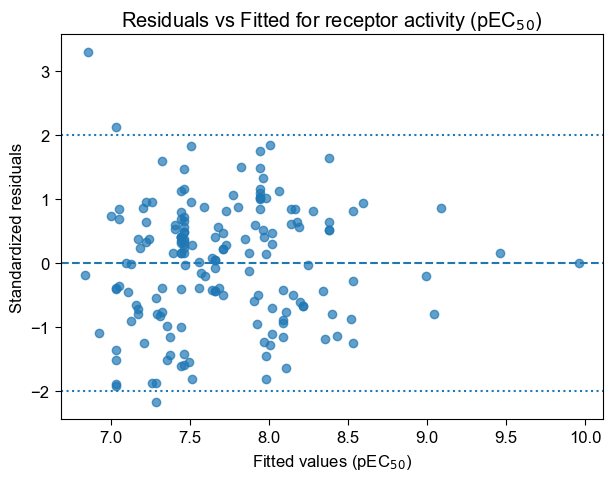

Residual summary:
count    1.690000e+02
mean     3.849649e-16
std      9.536816e-01
min     -2.172239e+00
25%     -7.066706e-01
50%      1.516831e-01
75%      6.377965e-01
max      3.299782e+00
dtype: float64


In [16]:
# ============================================================
# DIAGNOSTIC 1: Residuals vs Fitted (pEC50, Model A)
# using first imputation result directly
# ============================================================


# --- first imputation result from Model A
res_imp_1 = pEC50_readout_model["full_results"][0]

# --- fitted values and residuals
fitted_1 = res_imp_1.fittedvalues
residuals_1 = res_imp_1.resid

# --- standardized residuals
resid_sd_1 = np.sqrt(res_imp_1.scale)
std_residuals_1 = residuals_1 / resid_sd_1

# --- plot
plt.figure(figsize=(7,5))
plt.scatter(fitted_1, std_residuals_1, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.axhline(2, linestyle=":")
plt.axhline(-2, linestyle=":")

plt.xlabel("Fitted values (pEC$_5$$_0$)")
plt.ylabel("Standardized residuals")
plt.title("Residuals vs Fitted for receptor activity (pEC$_5$$_0$)")

plt.savefig("residuals_vs_fitted_pEC50_modelA.png", dpi=300, bbox_inches="tight")
plt.show()

print("Residual summary:")
print(pd.Series(std_residuals_1).describe())

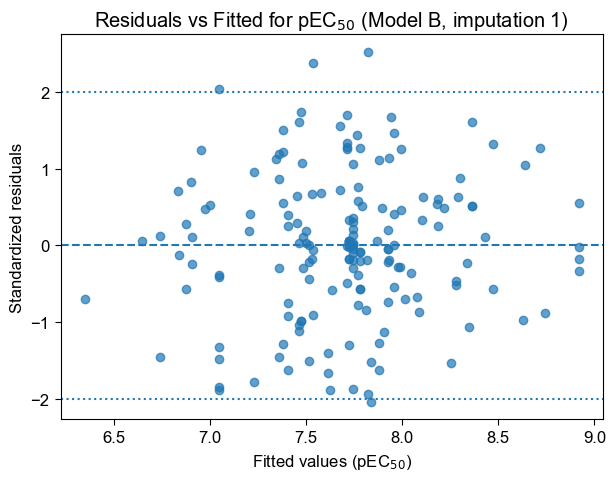

Residual summary:
count    1.690000e+02
mean    -1.602926e-16
std      9.413080e-01
min     -2.043171e+00
25%     -5.664946e-01
50%      8.507507e-04
75%      5.579514e-01
max      2.524416e+00
dtype: float64


In [17]:
# ============================================================
# DIAGNOSTIC 1: Residuals vs Fitted (pEC50, Model B)
# using first imputation result directly
# ============================================================


# --- first imputation result from Model B
res_imp_1 = pEC50_membrane_model["full_results"][0]

# --- fitted values and residuals
fitted_1 = res_imp_1.fittedvalues
residuals_1 = res_imp_1.resid

# --- standardized residuals
resid_sd_1 = np.sqrt(res_imp_1.scale)
std_residuals_1 = residuals_1 / resid_sd_1

# --- plot
plt.figure(figsize=(7,5))
plt.scatter(fitted_1, std_residuals_1, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.axhline(2, linestyle=":")
plt.axhline(-2, linestyle=":")

plt.xlabel("Fitted values (pEC$_5$$_0$)")
plt.ylabel("Standardized residuals")
plt.title("Residuals vs Fitted for pEC$_5$$_0$ (Model B, imputation 1)")

plt.savefig("residuals_vs_fitted_pEC50_modelB.png", dpi=300, bbox_inches="tight")
plt.show()

print("Residual summary:")
print(pd.Series(std_residuals_1).describe())

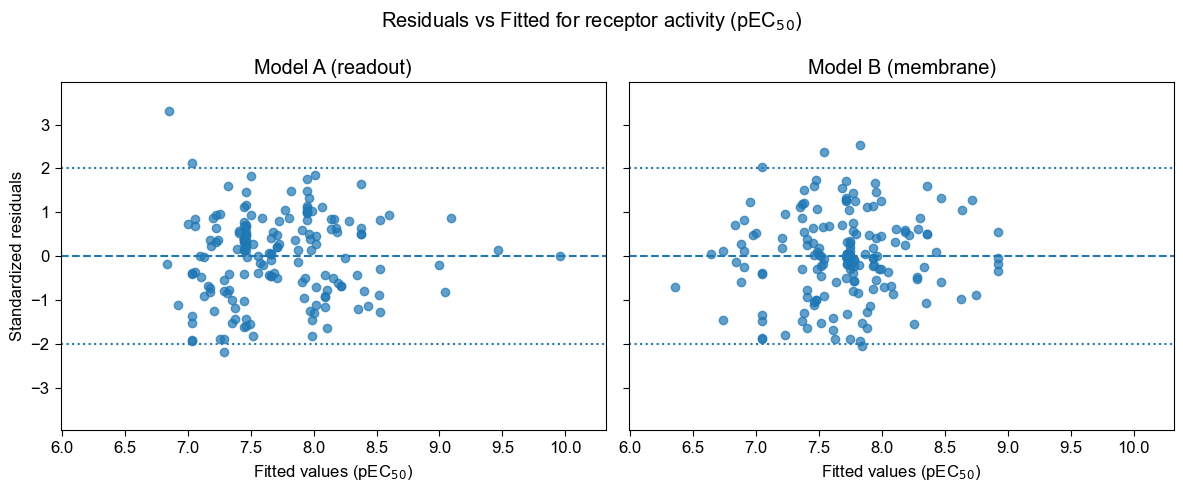

In [18]:
# ============================================================
# DIAGNOSTIC: Residuals vs Fitted (Model A vs Model B)
# side-by-side with identical axes
# ============================================================

# ------------------------------------------------------------
# 1) Extract model results (imputation 1)
# ------------------------------------------------------------
res_A = pEC50_readout_model["full_results"][0]
res_B = pEC50_membrane_model["full_results"][0]

# ------------------------------------------------------------
# 2) Compute fitted + standardized residuals
# ------------------------------------------------------------
def get_residual_data(res):
    fitted = res.fittedvalues
    resid = res.resid
    std_resid = resid / np.sqrt(res.scale)
    return fitted, std_resid

fitted_A, std_resid_A = get_residual_data(res_A)
fitted_B, std_resid_B = get_residual_data(res_B)

# ------------------------------------------------------------
# 3) Define COMMON axis limits
# ------------------------------------------------------------
x_min = min(fitted_A.min(), fitted_B.min())
x_max = max(fitted_A.max(), fitted_B.max())

y_min = min(std_resid_A.min(), std_resid_B.min())
y_max = max(std_resid_A.max(), std_resid_B.max())

# optional: make symmetric y-axis
y_abs = max(abs(y_min), abs(y_max))
y_min, y_max = -y_abs, y_abs

# small padding
x_pad = 0.1 * (x_max - x_min)
y_pad = 0.1 * (y_max - y_min)

x_min -= x_pad
x_max += x_pad
y_min -= y_pad
y_max += y_pad

# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ---- Model A
axes[0].scatter(fitted_A, std_resid_A, alpha=0.7)
axes[0].axhline(0, linestyle="--")
axes[0].axhline(2, linestyle=":")
axes[0].axhline(-2, linestyle=":")
axes[0].set_title("Model A (readout)")
axes[0].set_xlabel("Fitted values (pEC$_5$$_0$)")
axes[0].set_ylabel("Standardized residuals")
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

# ---- Model B
axes[1].scatter(fitted_B, std_resid_B, alpha=0.7)
axes[1].axhline(0, linestyle="--")
axes[1].axhline(2, linestyle=":")
axes[1].axhline(-2, linestyle=":")
axes[1].set_title("Model B (membrane)")
axes[1].set_xlabel("Fitted values (pEC$_5$$_0$)")
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

# clean layout
plt.suptitle("Residuals vs Fitted for receptor activity (pEC$_5$$_0$)")
plt.tight_layout()

# save
plt.savefig("residuals_vs_fitted_pEC50_modelA_vs_modelB.png", dpi=300, bbox_inches="tight")

plt.show()

### Residuals vs Substance

Residual summary by substance:
substance      substance_label  n  mean_std_residual  sd_std_residual  min_std_residual  max_std_residual  median_std_residual
155532408 CHEMBL4467516 (n=12) 12          -0.259472         1.288904         -2.172239          3.299782            -0.447043
 10382701        JWH-018 (n=7)  7          -0.064373         0.778012         -0.609286          1.595454            -0.419257
    16078        Δ⁹-THC (n=13) 13          -0.279778         1.205086         -1.931543          2.119009            -0.384829
 71819307        JWH-018 (n=6)  6           0.170927         1.050823         -0.904969          1.825661            -0.022748
   104895      CP55,940 (n=57) 57          -0.004829         0.877993         -1.815151          1.753755             0.048160
   104850    Rimonabant (n=19) 19           0.058994         1.070629         -1.820432          1.849054             0.279466
  5311501   WIN55,212-2 (n=17) 17           0.023855         0.765759         -1

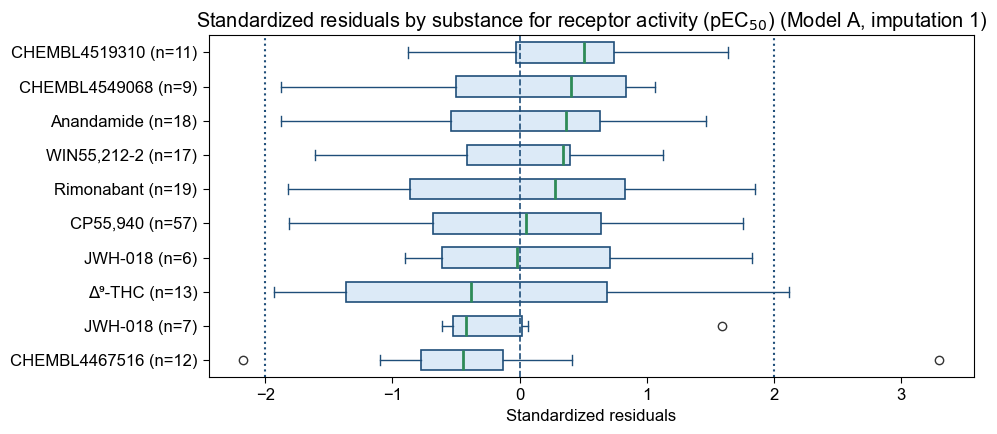

In [19]:
# ============================================================
# DIAGNOSTIC 2A: Standardized residuals by substance
# pEC50, Model A, imputation 1
# ============================================================


# ------------------------------------------------------------
# 1) Mapping pubchem_cid -> substance name
#    Bitte bei Bedarf anpassen
# ------------------------------------------------------------
compound_name_map = {
    "104895": "CP55,940",
    "104850": "Rimonabant",
    "10382701": "JWH-018",
    "5311501": "WIN55,212-2",
    "16078": "Δ⁹-THC",
    "4402318": "Anandamide",
    "155532408": "CHEMBL4467516",
    "155541870": "CHEMBL4519310",
    "155491029": "CHEMBL4549068",
    "71819307": "JWH-018",
}

# ------------------------------------------------------------
# 2) take first imputation result directly from Model A
# ------------------------------------------------------------
res_imp_1 = pEC50_readout_model["full_results"][0]

# underlying dataframe used for this fitted model
df_imp_1 = res_imp_1.model.data.frame.copy()

# group variable name from model formula object
group_col = res_imp_1.model.groups.name if hasattr(res_imp_1.model.groups, "name") else "pubchem_cid"

# ------------------------------------------------------------
# 3) residuals
# ------------------------------------------------------------
residuals_1 = res_imp_1.resid
std_residuals_1 = residuals_1 / np.sqrt(res_imp_1.scale)

# ------------------------------------------------------------
# 4) build diagnostic dataframe
# ------------------------------------------------------------
diag_substance_df = pd.DataFrame({
    "substance": df_imp_1[group_col].astype(str).values,
    "residual": residuals_1,
    "std_residual": std_residuals_1
})

# n per substance
n_df = (
    diag_substance_df.groupby("substance", as_index=False)
    .size()
    .rename(columns={"size": "n"})
)

diag_substance_df = diag_substance_df.merge(n_df, on="substance", how="left")

# nice labels with name + n
def make_substance_label(cid, n):
    pretty_name = compound_name_map.get(str(cid), str(cid))
    return f"{pretty_name} (n={int(n)})"

diag_substance_df["substance_label"] = diag_substance_df.apply(
    lambda row: make_substance_label(row["substance"], row["n"]),
    axis=1
)

# order by median standardized residual
order_df = (
    diag_substance_df.groupby(["substance", "substance_label"], as_index=False)
    .agg(median_std_residual=("std_residual", "median"))
    .sort_values("median_std_residual")
)

ordered_labels = order_df["substance_label"].tolist()

# summary table
substance_summary = (
    diag_substance_df.groupby(["substance", "substance_label"], as_index=False)
    .agg(
        n=("std_residual", "size"),
        mean_std_residual=("std_residual", "mean"),
        sd_std_residual=("std_residual", "std"),
        min_std_residual=("std_residual", "min"),
        max_std_residual=("std_residual", "max"),
        median_std_residual=("std_residual", "median")
    )
    .sort_values("median_std_residual")
)

print("Residual summary by substance:")
print(substance_summary.to_string(index=False))

# ------------------------------------------------------------
# 5) plot settings
# ------------------------------------------------------------
box_face = "#DCEAF7"
box_edge = "#1F4E79"
median_color = "#2E8B57"
whisker_color = "#1F4E79"
cap_color = "#1F4E79"
flier_edge = "#333333"

data_to_plot = [
    diag_substance_df.loc[
        diag_substance_df["substance_label"] == lab, "std_residual"
    ].values
    for lab in ordered_labels
]

# ------------------------------------------------------------
# 6) horizontal boxplot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4.5))

bp = ax.boxplot(
    data_to_plot,
    vert=False,
    patch_artist=True,
    labels=ordered_labels,
    widths=0.6,
    whis=1.5
)

for box in bp["boxes"]:
    box.set(facecolor=box_face, edgecolor=box_edge, linewidth=1.2)

for whisker in bp["whiskers"]:
    whisker.set(color=whisker_color, linewidth=1.0)

for cap in bp["caps"]:
    cap.set(color=cap_color, linewidth=1.0)

for median in bp["medians"]:
    median.set(color=median_color, linewidth=2.0)

for flier in bp["fliers"]:
    flier.set(
        marker="o",
        markerfacecolor="white",
        markeredgecolor=flier_edge,
        markersize=6,
        linestyle="none"
    )

ax.axvline(0, color=box_edge, linestyle="--", linewidth=1.2)
ax.axvline(2, color=box_edge, linestyle=":", linewidth=1.5)
ax.axvline(-2, color=box_edge, linestyle=":", linewidth=1.5)

ax.set_title("Standardized residuals by substance for receptor activity (pEC$_5$$_0$) (Model A, imputation 1)")
ax.set_xlabel("Standardized residuals")
ax.set_ylabel("")
ax.grid(False)

plt.tight_layout()
plt.savefig("standardized_residuals_by_substance_pEC50_modelA.png", dpi=300, bbox_inches="tight")
plt.show()

Residual summary by substance:
substance      substance_label  n  mean_std_residual  sd_std_residual  min_std_residual  max_std_residual  median_std_residual
    16078        Δ⁹-THC (n=13) 13          -0.224038         1.234092         -1.882566          2.035715            -0.386360
   104895      CP55,940 (n=57) 57           0.005812         0.961737         -1.935323          2.524416            -0.093423
 10382701        JWH-018 (n=7)  7          -0.006555         0.469489         -0.698012          0.507301            -0.015759
  5311501   WIN55,212-2 (n=17) 17          -0.065644         0.642804         -1.461404          1.189230            -0.001845
   104850    Rimonabant (n=19) 19           0.021576         1.163430         -2.043171          1.740693             0.003520
  4402318    Anandamide (n=18) 18          -0.055233         0.921345         -1.871693          1.508315             0.015527
 71819307        JWH-018 (n=6)  6           0.118285         0.943498         -1

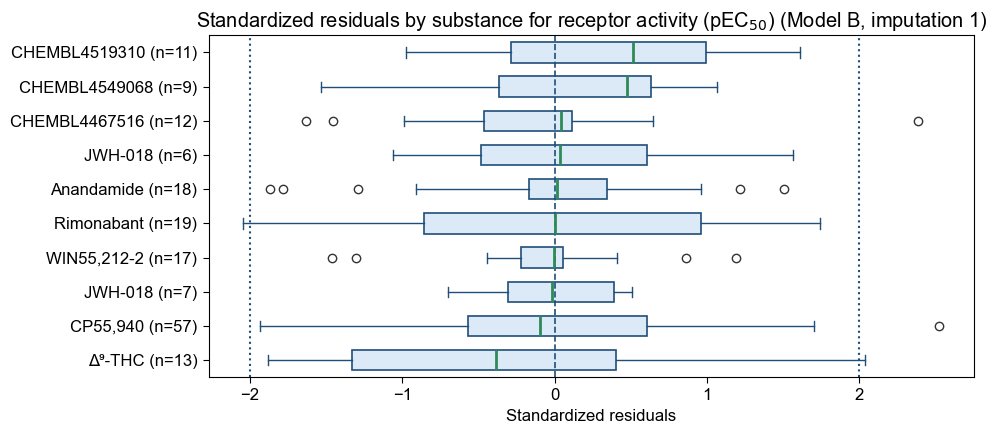

In [20]:
# ============================================================
# DIAGNOSTIC 2A: Standardized residuals by substance
# pEC50, Model A, imputation 1
# ============================================================


# ------------------------------------------------------------
# 1) Mapping pubchem_cid -> substance name
#    Bitte bei Bedarf anpassen
# ------------------------------------------------------------
compound_name_map = {
    "104895": "CP55,940",
    "104850": "Rimonabant",
    "10382701": "JWH-018",
    "5311501": "WIN55,212-2",
    "16078": "Δ⁹-THC",
    "4402318": "Anandamide",
    "155532408": "CHEMBL4467516",
    "155541870": "CHEMBL4519310",
    "155491029": "CHEMBL4549068",
    "71819307": "JWH-018",
}

# ------------------------------------------------------------
# 2) take first imputation result directly from Model A
# ------------------------------------------------------------
res_imp_1 = pEC50_membrane_model["full_results"][0]

# underlying dataframe used for this fitted model
df_imp_1 = res_imp_1.model.data.frame.copy()

# group variable name from model formula object
group_col = res_imp_1.model.groups.name if hasattr(res_imp_1.model.groups, "name") else "pubchem_cid"

# ------------------------------------------------------------
# 3) residuals
# ------------------------------------------------------------
residuals_1 = res_imp_1.resid
std_residuals_1 = residuals_1 / np.sqrt(res_imp_1.scale)

# ------------------------------------------------------------
# 4) build diagnostic dataframe
# ------------------------------------------------------------
diag_substance_df = pd.DataFrame({
    "substance": df_imp_1[group_col].astype(str).values,
    "residual": residuals_1,
    "std_residual": std_residuals_1
})

# n per substance
n_df = (
    diag_substance_df.groupby("substance", as_index=False)
    .size()
    .rename(columns={"size": "n"})
)

diag_substance_df = diag_substance_df.merge(n_df, on="substance", how="left")

# nice labels with name + n
def make_substance_label(cid, n):
    pretty_name = compound_name_map.get(str(cid), str(cid))
    return f"{pretty_name} (n={int(n)})"

diag_substance_df["substance_label"] = diag_substance_df.apply(
    lambda row: make_substance_label(row["substance"], row["n"]),
    axis=1
)

# order by median standardized residual
order_df = (
    diag_substance_df.groupby(["substance", "substance_label"], as_index=False)
    .agg(median_std_residual=("std_residual", "median"))
    .sort_values("median_std_residual")
)

ordered_labels = order_df["substance_label"].tolist()

# summary table
substance_summary = (
    diag_substance_df.groupby(["substance", "substance_label"], as_index=False)
    .agg(
        n=("std_residual", "size"),
        mean_std_residual=("std_residual", "mean"),
        sd_std_residual=("std_residual", "std"),
        min_std_residual=("std_residual", "min"),
        max_std_residual=("std_residual", "max"),
        median_std_residual=("std_residual", "median")
    )
    .sort_values("median_std_residual")
)

print("Residual summary by substance:")
print(substance_summary.to_string(index=False))

# ------------------------------------------------------------
# 5) plot settings
# ------------------------------------------------------------
box_face = "#DCEAF7"
box_edge = "#1F4E79"
median_color = "#2E8B57"
whisker_color = "#1F4E79"
cap_color = "#1F4E79"
flier_edge = "#333333"

data_to_plot = [
    diag_substance_df.loc[
        diag_substance_df["substance_label"] == lab, "std_residual"
    ].values
    for lab in ordered_labels
]

# ------------------------------------------------------------
# 6) horizontal boxplot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4.5))

bp = ax.boxplot(
    data_to_plot,
    vert=False,
    patch_artist=True,
    labels=ordered_labels,
    widths=0.6,
    whis=1.5
)

for box in bp["boxes"]:
    box.set(facecolor=box_face, edgecolor=box_edge, linewidth=1.2)

for whisker in bp["whiskers"]:
    whisker.set(color=whisker_color, linewidth=1.0)

for cap in bp["caps"]:
    cap.set(color=cap_color, linewidth=1.0)

for median in bp["medians"]:
    median.set(color=median_color, linewidth=2.0)

for flier in bp["fliers"]:
    flier.set(
        marker="o",
        markerfacecolor="white",
        markeredgecolor=flier_edge,
        markersize=6,
        linestyle="none"
    )

ax.axvline(0, color=box_edge, linestyle="--", linewidth=1.2)
ax.axvline(2, color=box_edge, linestyle=":", linewidth=1.5)
ax.axvline(-2, color=box_edge, linestyle=":", linewidth=1.5)

ax.set_title("Standardized residuals by substance for receptor activity (pEC$_5$$_0$) (Model B, imputation 1)")
ax.set_xlabel("Standardized residuals")
ax.set_ylabel("")
ax.grid(False)

plt.tight_layout()
plt.savefig("standardized_residuals_by_substance_pEC50_modelA.png", dpi=300, bbox_inches="tight")
plt.show()

Residual summary by substance — Model A
substance      substance_label  n  mean_std_residual  sd_std_residual  min_std_residual  max_std_residual  median_std_residual
155532408 CHEMBL4519310 (n=12) 12          -0.259472         1.288904         -2.172239          3.299782            -0.447043
 10382701        JWH-018 (n=7)  7          -0.064373         0.778012         -0.609286          1.595454            -0.419257
    16078        Δ⁹-THC (n=13) 13          -0.279778         1.205086         -1.931543          2.119009            -0.384829
 71819307         ZCZ011 (n=6)  6           0.170927         1.050823         -0.904969          1.825661            -0.022748
   104895      CP55,940 (n=57) 57          -0.004829         0.877993         -1.815151          1.753755             0.048160
   104850    Rimonabant (n=19) 19           0.058994         1.070629         -1.820432          1.849054             0.279466
  5311501   WIN55,212-2 (n=17) 17           0.023855         0.765759  

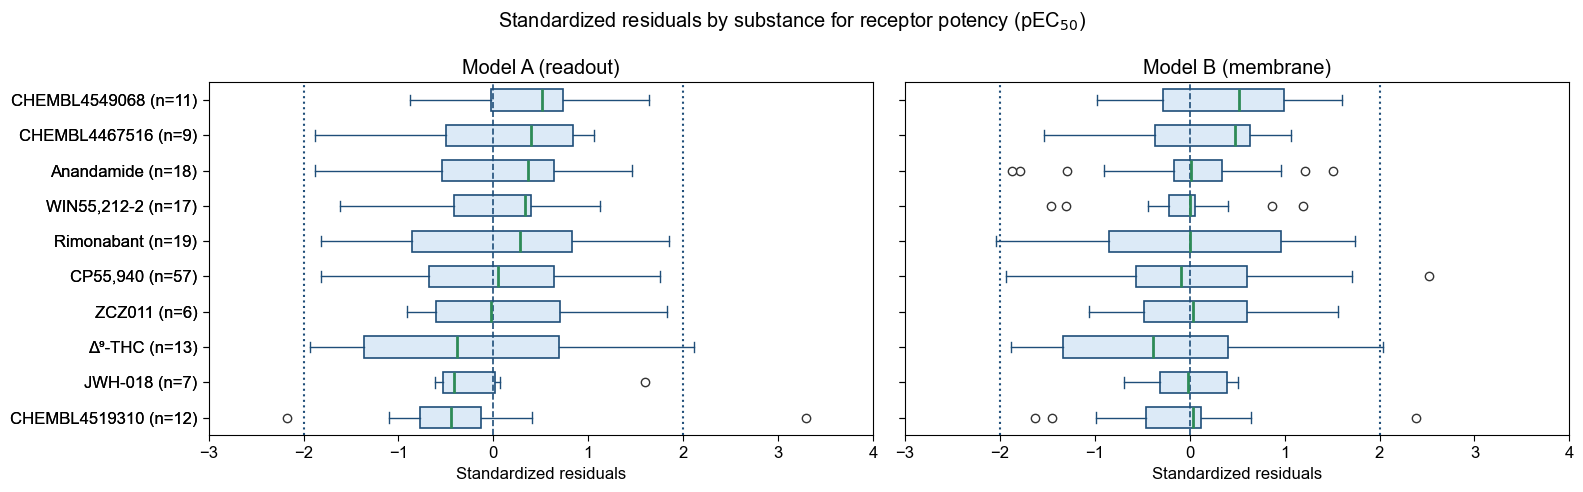

In [21]:
# ============================================================
# DIAGNOSTIC: Standardized residuals by substance
# pEC50 Model A vs Model B, imputation 1
# side-by-side with identical substance order and x-axis
# ============================================================

# ------------------------------------------------------------
# 1) Mapping pubchem_cid -> substance name
#    Bitte bei Bedarf anpassen
# ------------------------------------------------------------
compound_name_map = {
    "104895": "CP55,940",
    "104850": "Rimonabant",
    "10382701": "JWH-018",
    "5311501": "WIN55,212-2",
    "16078": "Δ⁹-THC",
    "4402318": "Anandamide",
    "155532408": "CHEMBL4519310",
    "155541870": "CHEMBL4549068",
    "155491029": "CHEMBL4467516",
    "71819307": "ZCZ011"
}

# ------------------------------------------------------------
# 2) Helper to extract residual dataframe from one model result
# ------------------------------------------------------------
def build_diag_substance_df(model_dict):
    res_imp_1 = model_dict["full_results"][0]
    df_imp_1 = res_imp_1.model.data.frame.copy()
    group_col = res_imp_1.model.groups.name if hasattr(res_imp_1.model.groups, "name") else "pubchem_cid"

    residuals = res_imp_1.resid
    std_residuals = residuals / np.sqrt(res_imp_1.scale)

    diag_df = pd.DataFrame({
        "substance": df_imp_1[group_col].astype(str).values,
        "residual": residuals,
        "std_residual": std_residuals
    })

    n_df = (
        diag_df.groupby("substance", as_index=False)
        .size()
        .rename(columns={"size": "n"})
    )
    diag_df = diag_df.merge(n_df, on="substance", how="left")

    def make_substance_label(cid, n):
        pretty_name = compound_name_map.get(str(cid), str(cid))
        return f"{pretty_name} (n={int(n)})"

    diag_df["substance_label"] = diag_df.apply(
        lambda row: make_substance_label(row["substance"], row["n"]),
        axis=1
    )

    return diag_df

# ------------------------------------------------------------
# 3) Build diagnostic dfs for Model A and Model B
# ------------------------------------------------------------
diag_A = build_diag_substance_df(pEC50_readout_model)
diag_B = build_diag_substance_df(pEC50_membrane_model)

# ------------------------------------------------------------
# 4) Common order: derive from Model A median residuals
# ------------------------------------------------------------
order_A = (
    diag_A.groupby(["substance", "substance_label"], as_index=False)
    .agg(median_std_residual=("std_residual", "median"))
    .sort_values("median_std_residual")
)

ordered_labels = order_A["substance_label"].tolist()

# keep only labels present in both models, preserving Model A order
labels_A = set(diag_A["substance_label"].unique())
labels_B = set(diag_B["substance_label"].unique())
ordered_labels_common = [lab for lab in ordered_labels if lab in labels_A and lab in labels_B]

# optional: if you want all labels from A, even if missing in B, use:
# ordered_labels_common = ordered_labels

# ------------------------------------------------------------
# 5) Summary tables
# ------------------------------------------------------------
summary_A = (
    diag_A.groupby(["substance", "substance_label"], as_index=False)
    .agg(
        n=("std_residual", "size"),
        mean_std_residual=("std_residual", "mean"),
        sd_std_residual=("std_residual", "std"),
        min_std_residual=("std_residual", "min"),
        max_std_residual=("std_residual", "max"),
        median_std_residual=("std_residual", "median")
    )
)

summary_B = (
    diag_B.groupby(["substance", "substance_label"], as_index=False)
    .agg(
        n=("std_residual", "size"),
        mean_std_residual=("std_residual", "mean"),
        sd_std_residual=("std_residual", "std"),
        min_std_residual=("std_residual", "min"),
        max_std_residual=("std_residual", "max"),
        median_std_residual=("std_residual", "median")
    )
)

print("Residual summary by substance — Model A")
print(summary_A.sort_values("median_std_residual").to_string(index=False))

print("\nResidual summary by substance — Model B")
print(summary_B.sort_values("median_std_residual").to_string(index=False))

# ------------------------------------------------------------
# 6) Data in common order
# ------------------------------------------------------------
data_A = [
    diag_A.loc[diag_A["substance_label"] == lab, "std_residual"].values
    for lab in ordered_labels_common
]

data_B = [
    diag_B.loc[diag_B["substance_label"] == lab, "std_residual"].values
    for lab in ordered_labels_common
]

# ------------------------------------------------------------
# 7) Common x-axis limits
# ------------------------------------------------------------
all_vals = np.concatenate([
    np.concatenate([x for x in data_A if len(x) > 0]),
    np.concatenate([x for x in data_B if len(x) > 0])
])

x_min = np.floor(all_vals.min() - 0.3)
x_max = np.ceil(all_vals.max() + 0.3)

# optional fixed symmetric axis:
# x_abs = max(abs(all_vals.min()), abs(all_vals.max()))
# x_min, x_max = -np.ceil(x_abs + 0.3), np.ceil(x_abs + 0.3)

# ------------------------------------------------------------
# 8) Plot settings
# ------------------------------------------------------------
box_face = "#DCEAF7"
box_edge = "#1F4E79"
median_color = "#2E8B57"
whisker_color = "#1F4E79"
cap_color = "#1F4E79"
flier_edge = "#333333"

def style_boxplot(bp):
    for box in bp["boxes"]:
        box.set(facecolor=box_face, edgecolor=box_edge, linewidth=1.2)
    for whisker in bp["whiskers"]:
        whisker.set(color=whisker_color, linewidth=1.0)
    for cap in bp["caps"]:
        cap.set(color=cap_color, linewidth=1.0)
    for median in bp["medians"]:
        median.set(color=median_color, linewidth=2.0)
    for flier in bp["fliers"]:
        flier.set(
            marker="o",
            markerfacecolor="white",
            markeredgecolor=flier_edge,
            markersize=6,
            linestyle="none"
        )

# ------------------------------------------------------------
# 9) Side-by-side plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, 0.45 * len(ordered_labels_common))), sharey=True)

# Model A
bp_A = axes[0].boxplot(
    data_A,
    vert=False,
    patch_artist=True,
    labels=ordered_labels_common,
    widths=0.6,
    whis=1.5
)
style_boxplot(bp_A)
axes[0].axvline(0, color=box_edge, linestyle="--", linewidth=1.2)
axes[0].axvline(2, color=box_edge, linestyle=":", linewidth=1.5)
axes[0].axvline(-2, color=box_edge, linestyle=":", linewidth=1.5)
axes[0].set_title("Model A (readout)")
axes[0].set_xlabel("Standardized residuals")
axes[0].set_ylabel("")
axes[0].set_xlim(x_min, x_max)
axes[0].grid(False)

# Model B
bp_B = axes[1].boxplot(
    data_B,
    vert=False,
    patch_artist=True,
    labels=ordered_labels_common,
    widths=0.6,
    whis=1.5
)
style_boxplot(bp_B)
axes[1].axvline(0, color=box_edge, linestyle="--", linewidth=1.2)
axes[1].axvline(2, color=box_edge, linestyle=":", linewidth=1.5)
axes[1].axvline(-2, color=box_edge, linestyle=":", linewidth=1.5)
axes[1].set_title("Model B (membrane)")
axes[1].set_xlabel("Standardized residuals")
axes[1].set_ylabel("")
axes[1].set_xlim(x_min, x_max)
axes[1].grid(False)

plt.suptitle("Standardized residuals by substance for receptor potency (pEC$_5$$_0$)")
plt.tight_layout()
plt.savefig("standardized_residuals_by_substance_pEC50_modelA_vs_modelB.png", dpi=300, bbox_inches="tight")
plt.show()

### Random intercept per substance

Random intercepts by substance:
substance  n  random_intercept                label
    16078 13         -0.366956        Δ⁹-THC (n=13)
155532408 12         -0.314143 CHEMBL4519310 (n=12)
 10382701  7         -0.045463        JWH-018 (n=7)
   104895 57         -0.027773      CP55,940 (n=57)
155491029  9          0.034313  CHEMBL4467516 (n=9)
  5311501 17          0.040916   WIN55,212-2 (n=17)
  4402318 18          0.058219    Anandamide (n=18)
 71819307  6          0.103471         ZCZ011 (n=6)
   104850 19          0.113088    Rimonabant (n=19)
155541870 11          0.404329 CHEMBL4549068 (n=11)


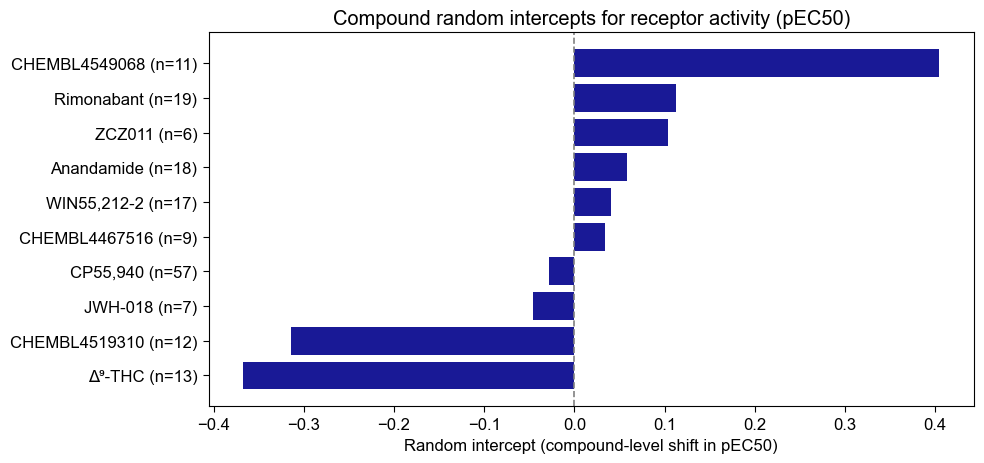

In [22]:
# ============================================================
# DIAGNOSTIC B: Random intercepts by substance
# pEC50, Model A, imputation 1
# ============================================================



# ------------------------------------------------------------
# 1) Mapping pubchem_cid -> nicer substance name
# ------------------------------------------------------------
compound_name_map = {
    "104895": "CP55,940",
    "104850": "Rimonabant",
    "10382701": "JWH-018",
    "5311501": "WIN55,212-2",
    "16078": "Δ⁹-THC",
    "4402318": "Anandamide",
    "155532408": "CHEMBL4519310",
    "155541870": "CHEMBL4549068",
    "155491029": "CHEMBL4467516",
    "71819307": "ZCZ011"
}

# ------------------------------------------------------------
# 2) take first imputation result directly from Model A
# ------------------------------------------------------------
res_imp_1 = pEC50_readout_model["full_results"][0]

# underlying dataframe used for this fitted model
df_imp_1 = res_imp_1.model.data.frame.copy()

# group variable name
group_col = res_imp_1.model.groups.name if hasattr(res_imp_1.model.groups, "name") else "pubchem_cid"

# ------------------------------------------------------------
# 3) extract random intercepts
# ------------------------------------------------------------
re_dict = res_imp_1.random_effects

random_intercepts = []
for substance, effect in re_dict.items():
    if hasattr(effect, "iloc"):
        val = float(effect.iloc[0])
    elif isinstance(effect, (list, tuple, np.ndarray)):
        val = float(effect[0])
    else:
        val = float(effect)

    random_intercepts.append({
        "substance": str(substance),
        "random_intercept": val
    })

re_df = pd.DataFrame(random_intercepts)

# ------------------------------------------------------------
# 4) add n per substance
# ------------------------------------------------------------
n_df = (
    df_imp_1.groupby(group_col, as_index=False)
    .size()
    .rename(columns={group_col: "substance", "size": "n"})
)
n_df["substance"] = n_df["substance"].astype(str)

re_df = re_df.merge(n_df, on="substance", how="left")

# ------------------------------------------------------------
# 5) build pretty labels
# ------------------------------------------------------------
def make_substance_label(cid, n):
    pretty_name = compound_name_map.get(str(cid), str(cid))
    return f"{pretty_name} (n={int(n)})"

re_df["label"] = re_df.apply(
    lambda row: make_substance_label(row["substance"], row["n"]),
    axis=1
)

# sort from lowest to highest random intercept
re_df = re_df.sort_values("random_intercept").reset_index(drop=True)

print("Random intercepts by substance:")
print(re_df[["substance", "n", "random_intercept", "label"]].to_string(index=False))

# ------------------------------------------------------------
# 6) plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 4.8))

plt.barh(
    re_df["label"],
    re_df["random_intercept"],
    color="darkblue",
    alpha=0.9
)

plt.axvline(0, color="grey", linestyle="--", linewidth=1.2)
plt.grid(False)

plt.xlabel("Random intercept (compound-level shift in pEC50)")
plt.ylabel("")
plt.title("Compound random intercepts for receptor activity (pEC50)")

plt.tight_layout()
plt.savefig("compound_random_intercept_pEC50_modelA.png", dpi=300, bbox_inches="tight")
plt.show()

Random intercepts by substance:
substance  n  random_intercept                label
    16078 13         -0.507161        Δ⁹-THC (n=13)
155532408 12         -0.203182 CHEMBL4519310 (n=12)
  5311501 17         -0.194324   WIN55,212-2 (n=17)
  4402318 18         -0.173123    Anandamide (n=18)
 10382701  7         -0.007990        JWH-018 (n=7)
   104895 57          0.057689      CP55,940 (n=57)
   104850 19          0.071386    Rimonabant (n=19)
 71819307  6          0.123584         ZCZ011 (n=6)
155491029  9          0.127237  CHEMBL4467516 (n=9)
155541870 11          0.705884 CHEMBL4549068 (n=11)


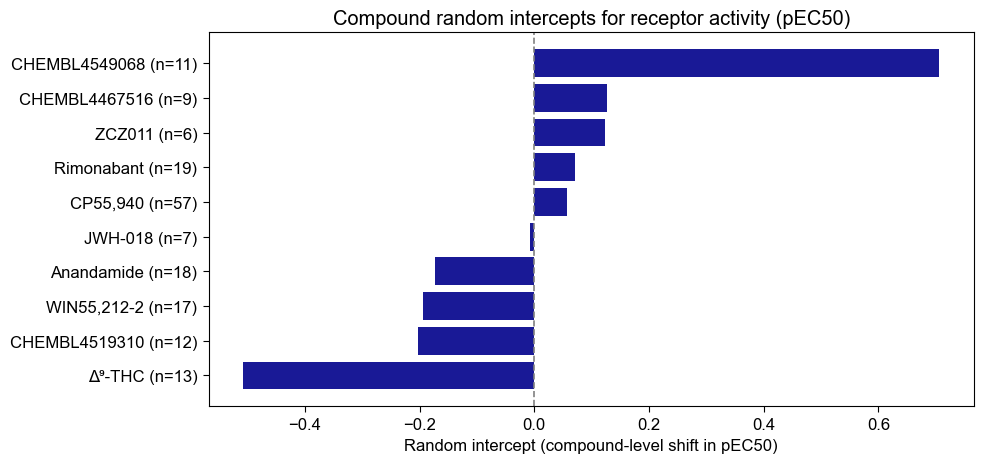

In [23]:
# ============================================================
# DIAGNOSTIC B: Random intercepts by substance
# pEC50, Model B, imputation 1
# ============================================================

compound_name_map = {
    "104895": "CP55,940",
    "104850": "Rimonabant",
    "10382701": "JWH-018",
    "5311501": "WIN55,212-2",
    "16078": "Δ⁹-THC",
    "4402318": "Anandamide",
    "155532408": "CHEMBL4519310",
    "155541870": "CHEMBL4549068",
    "155491029": "CHEMBL4467516",
    "71819307": "ZCZ011"
}

res_imp_1 = pEC50_membrane_model["full_results"][0]
df_imp_1 = res_imp_1.model.data.frame.copy()
group_col = res_imp_1.model.groups.name if hasattr(res_imp_1.model.groups, "name") else "pubchem_cid"

re_dict = res_imp_1.random_effects

random_intercepts = []
for substance, effect in re_dict.items():
    if hasattr(effect, "iloc"):
        val = float(effect.iloc[0])
    elif isinstance(effect, (list, tuple, np.ndarray)):
        val = float(effect[0])
    else:
        val = float(effect)

    random_intercepts.append({
        "substance": str(substance),
        "random_intercept": val
    })

re_df = pd.DataFrame(random_intercepts)

n_df = (
    df_imp_1.groupby(group_col, as_index=False)
    .size()
    .rename(columns={group_col: "substance", "size": "n"})
)
n_df["substance"] = n_df["substance"].astype(str)

re_df = re_df.merge(n_df, on="substance", how="left")

def make_substance_label(cid, n):
    pretty_name = compound_name_map.get(str(cid), str(cid))
    return f"{pretty_name} (n={int(n)})"

re_df["label"] = re_df.apply(
    lambda row: make_substance_label(row["substance"], row["n"]),
    axis=1
)

re_df = re_df.sort_values("random_intercept").reset_index(drop=True)

print("Random intercepts by substance:")
print(re_df[["substance", "n", "random_intercept", "label"]].to_string(index=False))

plt.figure(figsize=(10, 4.8))

plt.barh(
    re_df["label"],
    re_df["random_intercept"],
    color="darkblue",
    alpha=0.9
)

plt.axvline(0, color="grey", linestyle="--", linewidth=1.2)
plt.grid(False)

plt.xlabel("Random intercept (compound-level shift in pEC50)")
plt.ylabel("")
plt.title("Compound random intercepts for receptor activity (pEC50)")

plt.tight_layout()
plt.savefig("compound_random_intercept_pEC50_modelB.png", dpi=300, bbox_inches="tight")
plt.show()

Random intercepts by substance:
substance  n  random_intercept                label
  5311501 17         -0.421334   WIN55,212-2 (n=17)
155532408 12         -0.418768 CHEMBL4519310 (n=12)
  4402318 18         -0.399947    Anandamide (n=18)
    16078 13         -0.150589        Δ⁹-THC (n=13)
 10382701  7          0.046924        JWH-018 (n=7)
 71819307  6          0.090087         ZCZ011 (n=6)
155491029  9          0.157488  CHEMBL4467516 (n=9)
   104850 19          0.211883    Rimonabant (n=19)
   104895 57          0.240719      CP55,940 (n=57)
155541870 11          0.643537 CHEMBL4549068 (n=11)


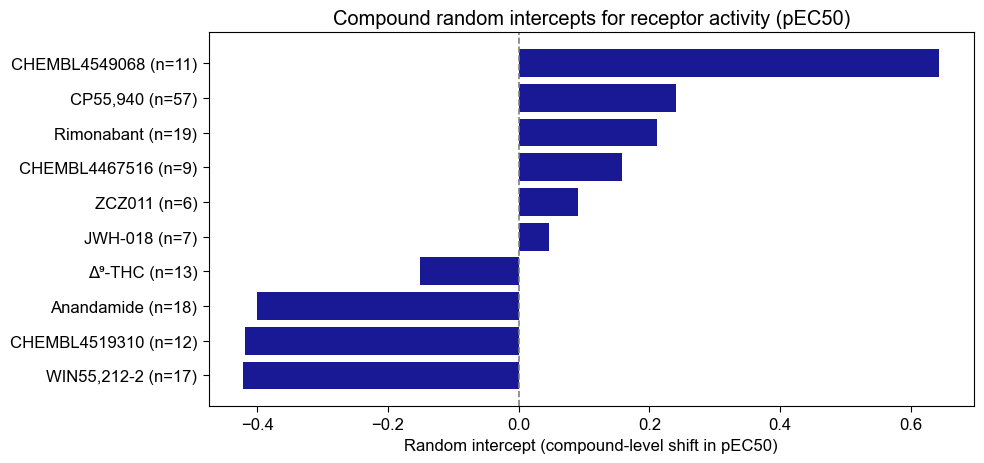

In [24]:
# ============================================================
# DIAGNOSTIC C: Random intercepts by substance
# pEC50, Model C, imputation 1
# ============================================================

compound_name_map = {
    "104895": "CP55,940",
    "104850": "Rimonabant",
    "10382701": "JWH-018",
    "5311501": "WIN55,212-2",
    "16078": "Δ⁹-THC",
    "4402318": "Anandamide",
    "155532408": "CHEMBL4519310",
    "155541870": "CHEMBL4549068",
    "155491029": "CHEMBL4467516",
    "71819307": "ZCZ011"
}

res_imp_1 = pEC50_assayname_model["full_results"][0]
df_imp_1 = res_imp_1.model.data.frame.copy()
group_col = res_imp_1.model.groups.name if hasattr(res_imp_1.model.groups, "name") else "pubchem_cid"

re_dict = res_imp_1.random_effects

random_intercepts = []
for substance, effect in re_dict.items():
    if hasattr(effect, "iloc"):
        val = float(effect.iloc[0])
    elif isinstance(effect, (list, tuple, np.ndarray)):
        val = float(effect[0])
    else:
        val = float(effect)

    random_intercepts.append({
        "substance": str(substance),
        "random_intercept": val
    })

re_df = pd.DataFrame(random_intercepts)

n_df = (
    df_imp_1.groupby(group_col, as_index=False)
    .size()
    .rename(columns={group_col: "substance", "size": "n"})
)
n_df["substance"] = n_df["substance"].astype(str)

re_df = re_df.merge(n_df, on="substance", how="left")

def make_substance_label(cid, n):
    pretty_name = compound_name_map.get(str(cid), str(cid))
    return f"{pretty_name} (n={int(n)})"

re_df["label"] = re_df.apply(
    lambda row: make_substance_label(row["substance"], row["n"]),
    axis=1
)

re_df = re_df.sort_values("random_intercept").reset_index(drop=True)

print("Random intercepts by substance:")
print(re_df[["substance", "n", "random_intercept", "label"]].to_string(index=False))

plt.figure(figsize=(10, 4.8))

plt.barh(
    re_df["label"],
    re_df["random_intercept"],
    color="darkblue",
    alpha=0.9
)

plt.axvline(0, color="grey", linestyle="--", linewidth=1.2)
plt.grid(False)

plt.xlabel("Random intercept (compound-level shift in pEC50)")
plt.ylabel("")
plt.title("Compound random intercepts for receptor activity (pEC50)")

plt.tight_layout()
plt.savefig("compound_random_intercept_pEC50_modelC.png", dpi=300, bbox_inches="tight")
plt.show()

Random intercepts by substance — Model A
substance  n  random_intercept                label
    16078 13         -0.366956        Δ⁹-THC (n=13)
155532408 12         -0.314143 CHEMBL4519310 (n=12)
 10382701  7         -0.045463        JWH-018 (n=7)
   104895 57         -0.027773      CP55,940 (n=57)
155491029  9          0.034313  CHEMBL4467516 (n=9)
  5311501 17          0.040916   WIN55,212-2 (n=17)
  4402318 18          0.058219    Anandamide (n=18)
 71819307  6          0.103471         ZCZ011 (n=6)
   104850 19          0.113088    Rimonabant (n=19)
155541870 11          0.404329 CHEMBL4549068 (n=11)

Random intercepts by substance — Model B
substance  n  random_intercept                label
    16078 13         -0.507161        Δ⁹-THC (n=13)
155532408 12         -0.203182 CHEMBL4519310 (n=12)
 10382701  7         -0.007990        JWH-018 (n=7)
   104895 57          0.057689      CP55,940 (n=57)
155491029  9          0.127237  CHEMBL4467516 (n=9)
  5311501 17         -0.194324   

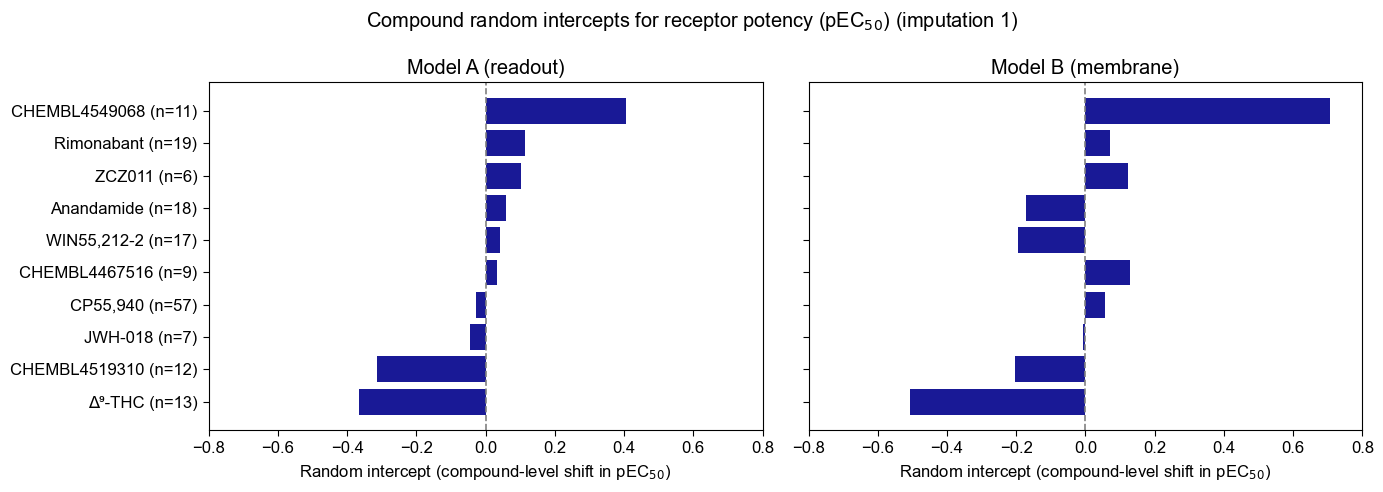

In [25]:
# ============================================================
# DIAGNOSTIC B: Random intercepts by substance
# pEC50, Model A vs Model B, imputation 1
# side-by-side with identical substance order and x-axis
# ============================================================


# ------------------------------------------------------------
# 1) Mapping pubchem_cid -> nicer substance name
# ------------------------------------------------------------
compound_name_map = {
    "104895": "CP55,940",
    "104850": "Rimonabant",
    "10382701": "JWH-018",
    "5311501": "WIN55,212-2",
    "16078": "Δ⁹-THC",
    "4402318": "Anandamide",
    "155532408": "CHEMBL4519310",
    "155541870": "CHEMBL4549068",
    "155491029": "CHEMBL4467516",
    "71819307": "ZCZ011"
}

# ------------------------------------------------------------
# 2) Helper to extract random intercept table from one model
# ------------------------------------------------------------
def build_random_intercept_df(model_dict):
    res_imp_1 = model_dict["full_results"][0]
    df_imp_1 = res_imp_1.model.data.frame.copy()
    group_col = res_imp_1.model.groups.name if hasattr(res_imp_1.model.groups, "name") else "pubchem_cid"

    re_dict = res_imp_1.random_effects

    random_intercepts = []
    for substance, effect in re_dict.items():
        if hasattr(effect, "iloc"):
            val = float(effect.iloc[0])
        elif isinstance(effect, (list, tuple, np.ndarray)):
            val = float(effect[0])
        else:
            val = float(effect)

        random_intercepts.append({
            "substance": str(substance),
            "random_intercept": val
        })

    re_df = pd.DataFrame(random_intercepts)

    n_df = (
        df_imp_1.groupby(group_col, as_index=False)
        .size()
        .rename(columns={group_col: "substance", "size": "n"})
    )
    n_df["substance"] = n_df["substance"].astype(str)

    re_df = re_df.merge(n_df, on="substance", how="left")

    def make_substance_label(cid, n):
        pretty_name = compound_name_map.get(str(cid), str(cid))
        return f"{pretty_name} (n={int(n)})"

    re_df["label"] = re_df.apply(
        lambda row: make_substance_label(row["substance"], row["n"]),
        axis=1
    )

    return re_df

# ------------------------------------------------------------
# 3) Build random-intercept tables
# ------------------------------------------------------------
re_A = build_random_intercept_df(pEC50_readout_model)
re_B = build_random_intercept_df(pEC50_membrane_model)

# ------------------------------------------------------------
# 4) Common order: derive from Model A
# ------------------------------------------------------------
re_A_sorted = re_A.sort_values("random_intercept").reset_index(drop=True)
ordered_labels = re_A_sorted["label"].tolist()

labels_A = set(re_A["label"].unique())
labels_B = set(re_B["label"].unique())
ordered_labels_common = [lab for lab in ordered_labels if lab in labels_A and lab in labels_B]

# reorder both dfs
re_A_plot = re_A.set_index("label").loc[ordered_labels_common].reset_index()
re_B_plot = re_B.set_index("label").loc[ordered_labels_common].reset_index()

print("Random intercepts by substance — Model A")
print(re_A_plot[["substance", "n", "random_intercept", "label"]].to_string(index=False))

print("\nRandom intercepts by substance — Model B")
print(re_B_plot[["substance", "n", "random_intercept", "label"]].to_string(index=False))

# ------------------------------------------------------------
# 5) Common x-axis
# ------------------------------------------------------------
all_vals = np.concatenate([
    re_A_plot["random_intercept"].values,
    re_B_plot["random_intercept"].values
])

x_abs = max(abs(all_vals.min()), abs(all_vals.max()))
x_lim = np.ceil((x_abs + 0.05) * 10) / 10

# ------------------------------------------------------------
# 6) Plot side-by-side
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, 0.45 * len(ordered_labels_common))), sharey=True)

# Model A
axes[0].barh(
    re_A_plot["label"],
    re_A_plot["random_intercept"],
    color="darkblue",
    alpha=0.9
)
axes[0].axvline(0, color="grey", linestyle="--", linewidth=1.2)
axes[0].grid(False)
axes[0].set_xlim(-x_lim, x_lim)
axes[0].set_title("Model A (readout)")
axes[0].set_xlabel("Random intercept (compound-level shift in pEC$_5$$_0$)")
axes[0].set_ylabel("")

# Model B
axes[1].barh(
    re_B_plot["label"],
    re_B_plot["random_intercept"],
    color="darkblue",
    alpha=0.9
)
axes[1].axvline(0, color="grey", linestyle="--", linewidth=1.2)
axes[1].grid(False)
axes[1].set_xlim(-x_lim, x_lim)
axes[1].set_title("Model B (membrane)")
axes[1].set_xlabel("Random intercept (compound-level shift in pEC$_5$$_0$)")
axes[1].set_ylabel("")

plt.suptitle("Compound random intercepts for receptor potency (pEC$_5$$_0$) (imputation 1)")
plt.tight_layout()
plt.savefig("compound_random_intercepts_pEC50_modelA_vs_modelB.png", dpi=300, bbox_inches="tight")
plt.show()

### Leave-one substance-out sensitivity analysis

In [26]:
# ============================================================
# Leave-one-substance-out sensitivity analysis
# for pEC50 MI-LMM models returned by run_pEC50_mi_lmm()
# ============================================================



# ------------------------------------------------------------
# helper: pool fixed effects from a list of fitted models
# ------------------------------------------------------------
def pool_fixed_effects_from_results(results_list):
    fe_params_list = []
    fe_cov_list = []

    for res in results_list:
        fe_names = res.fe_params.index.tolist()
        fe_params = res.fe_params.copy()
        fe_cov = res.cov_params().loc[fe_names, fe_names].copy()

        fe_params_list.append(fe_params)
        fe_cov_list.append(fe_cov)

    return pool_fixed_effects(fe_params_list, fe_cov_list)


# ------------------------------------------------------------
# main function
# ------------------------------------------------------------
def leave_one_substance_out_pEC50(model_dict, output_prefix=None):
    """
    Leave-one-substance-out sensitivity analysis for one pEC50 MI-LMM model.

    model_dict = output of run_pEC50_mi_lmm(...)
    """

    model_name = model_dict["model_name"]
    formula_fixed = model_dict["formula_fixed"]

    # all fitted MI results from the original model
    mi_results_full = model_dict["full_results"]

    # derive baseline pooled estimates
    pooled_full = pool_fixed_effects_from_results(mi_results_full).copy()
    pooled_full = pooled_full.rename(columns={"estimate": "estimate_full"})
    pooled_full = pooled_full[["term", "estimate_full"]]

    print(f"\n===== Leave-one-substance-out: {model_name} =====")
    print("Baseline pooled MI model ready.")
    print(pooled_full.to_string(index=False))

    # ------------------------------------------------------------
    # substances from first imputed dataset used in the fitted model
    # ------------------------------------------------------------
    df_imp_1 = mi_results_full[0].model.data.frame.copy()
    group_col = mi_results_full[0].model.groups.name if hasattr(mi_results_full[0].model.groups, "name") else "pubchem_cid"

    substances = sorted(pd.Series(df_imp_1[group_col].astype(str).unique()).tolist())

    loo_rows = []
    failed_substances = []

    # categorical columns from model frame
    # infer from formula design by taking all object/category cols except group
    categorical_cols = [
        c for c in df_imp_1.columns
        if c != group_col and (
            str(df_imp_1[c].dtype) == "category" or df_imp_1[c].dtype == object
        )
    ]

    # ------------------------------------------------------------
    # leave-one-substance-out
    # ------------------------------------------------------------
    for substance in substances:
        loo_results = []

        for res_full_m in mi_results_full:
            df_imp_m = res_full_m.model.data.frame.copy()
            df_loo = df_imp_m[df_imp_m[group_col].astype(str) != str(substance)].copy()

            # must still have at least 2 groups
            n_groups = df_loo[group_col].astype(str).nunique()
            if n_groups < 2:
                continue

            try:
                res_loo = fit_mixedlm_safe(
                    formula=formula_fixed,
                    data=df_loo,
                    group_col=group_col,
                    categorical_cols=categorical_cols,
                    reml=True
                )
                loo_results.append(res_loo)

            except Exception as e:
                failed_substances.append({
                    "left_out_substance": substance,
                    "error": str(e)
                })

        if len(loo_results) == 0:
            continue

        pooled_loo = pool_fixed_effects_from_results(loo_results).copy()
        pooled_loo = pooled_loo.rename(columns={"estimate": "estimate_loo"})
        pooled_loo = pooled_loo[["term", "estimate_loo"]]

        merged = pooled_full.merge(pooled_loo, on="term", how="inner")
        merged["left_out_substance"] = substance
        merged["abs_change"] = (merged["estimate_loo"] - merged["estimate_full"]).abs()

        merged["rel_change_pct"] = np.where(
            merged["estimate_full"].abs() > 1e-8,
            100 * merged["abs_change"] / merged["estimate_full"].abs(),
            np.nan
        )

        loo_rows.append(merged)

    if len(loo_rows) == 0:
        raise RuntimeError("No leave-one-substance-out models could be fitted.")

    loo_df = pd.concat(loo_rows, ignore_index=True)

    # ------------------------------------------------------------
    # summarize influence per coefficient
    # ------------------------------------------------------------
    summary_rows = []

    for term, subdf in loo_df.groupby("term"):
        idx_max = subdf["abs_change"].idxmax()

        summary_rows.append({
            "term": term,
            "max_abs_change": subdf["abs_change"].max(),
            "median_abs_change": subdf["abs_change"].median(),
            "worst_case_substance": loo_df.loc[idx_max, "left_out_substance"],
            "baseline_estimate": loo_df.loc[idx_max, "estimate_full"]
        })

    loo_summary = pd.DataFrame(summary_rows).sort_values(
        "max_abs_change", ascending=False
    )

    print("\nLeave-one-substance-out summary:")
    print(loo_summary.to_string(index=False))

    # ------------------------------------------------------------
    # failed fits
    # ------------------------------------------------------------
    if len(failed_substances) > 0:
        failed_df = pd.DataFrame(failed_substances).drop_duplicates()
        print("\nLeave-one-substance-out fits with errors:")
        print(failed_df.to_string(index=False))
    else:
        failed_df = pd.DataFrame(columns=["left_out_substance", "error"])
        print("\nAll leave-one-substance-out fits completed without recorded errors.")

    # ------------------------------------------------------------
    # optional export
    # ------------------------------------------------------------
    if output_prefix is None:
        output_prefix = model_name

    output_file = f"{output_prefix}_leave_one_substance_out.xlsx"
    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
        pooled_full.to_excel(writer, sheet_name="baseline_pooled", index=False)
        loo_df.to_excel(writer, sheet_name="loo_all_terms", index=False)
        loo_summary.to_excel(writer, sheet_name="loo_summary", index=False)
        failed_df.to_excel(writer, sheet_name="failed_fits", index=False)

    print(f"\nExcel file saved: {output_file}")

    return {
        "baseline_pooled": pooled_full,
        "loo_df": loo_df,
        "loo_summary": loo_summary,
        "failed_df": failed_df
    }

In [27]:
# ============================================================
# Leave-one-substance-out sensitivity analysis
# Model A: pEC50_readout_model
# ============================================================

pEC50_readout_loo = leave_one_substance_out_pEC50(
    model_dict=pEC50_readout_model,
    output_prefix="pEC50_readout_model"
)


===== Leave-one-substance-out: pEC50_readout_model =====
Baseline pooled MI model ready.
                                                                                   term  estimate_full
                                                                              Intercept       6.393543
                             C(receptor_species, Treatment(reference='human'))[T.mouse]      -0.761667
                               C(receptor_species, Treatment(reference='human'))[T.rat]      -0.369921
    C(assay_readout_clean, Treatment(reference='chemiluminescence'))[T.bioluminescence]      -0.206569
       C(assay_readout_clean, Treatment(reference='chemiluminescence'))[T.fluorescence]       0.957479
C(assay_readout_clean, Treatment(reference='chemiluminescence'))[T.fluorescence (HTRF)]       1.817136
 C(assay_readout_clean, Treatment(reference='chemiluminescence'))[T.fluorescence (TRF)]       2.742848
       C(assay_readout_clean, Treatment(reference='chemiluminescence'))[T.luminescence

In [28]:
# ============================================================
# Leave-one-substance-out sensitivity analysis
# Model B: pEC50_membrane_model
# ============================================================

pEC50_membrane_loo = leave_one_substance_out_pEC50(
    model_dict=pEC50_membrane_model,
    output_prefix="pEC50_membrane_model"
)


===== Leave-one-substance-out: pEC50_membrane_model =====
Baseline pooled MI model ready.
                                                                     term  estimate_full
                                                                Intercept       7.920209
               C(receptor_species, Treatment(reference='human'))[T.mouse]       0.243289
                 C(receptor_species, Treatment(reference='human'))[T.rat]       0.370167
                C(cell_membrane_clean, Treatment(reference='cho'))[T.AtT]       0.221174
              C(cell_membrane_clean, Treatment(reference='cho'))[T.brain]      -1.096541
             C(cell_membrane_clean, Treatment(reference='cho'))[T.chem-1]       1.177507
              C(cell_membrane_clean, Treatment(reference='cho'))[T.cos-7]      -0.345212
                C(cell_membrane_clean, Treatment(reference='cho'))[T.hek]       0.348899
               C(cell_membrane_clean, Treatment(reference='cho'))[T.htla]       1.081230
         C(cell_mem

### Observation-level Influence

In [29]:
# ============================================================
# DIAGNOSTIC C: Observation-level influence diagnostics
# for pEC50 MI-LMM models returned by run_pEC50_mi_lmm()
# ============================================================

def observation_influence_pEC50(model_dict, top_n=15, plot_filename=None):
    """
    Observation-level residual screening + leave-one-observation-out influence
    for one pEC50 MI-LMM model (imputation 1).
    """

    model_name = model_dict["model_name"]
    formula_fixed = model_dict["formula_fixed"]
    res_imp_1 = model_dict["full_results"][0]

    # underlying dataframe used for this fitted model
    df_imp_1 = res_imp_1.model.data.frame.copy()

    group_col = res_imp_1.model.groups.name if hasattr(res_imp_1.model.groups, "name") else "pubchem_cid"

    # infer categorical columns from model frame
    categorical_cols = [
        c for c in df_imp_1.columns
        if c != group_col and (
            str(df_imp_1[c].dtype) == "category" or df_imp_1[c].dtype == object
        )
    ]

    # keep original row id for traceability
    df_imp_1 = df_imp_1.reset_index(drop=False).rename(columns={"index": "original_row_id"})

    # ------------------------------------------------------------
    # fitted values and residuals
    # ------------------------------------------------------------
    diag_obs_df = df_imp_1.copy()
    diag_obs_df["fitted"] = res_imp_1.fittedvalues
    diag_obs_df["residual"] = res_imp_1.resid
    diag_obs_df["std_residual"] = diag_obs_df["residual"] / np.sqrt(res_imp_1.scale)
    diag_obs_df["abs_std_residual"] = diag_obs_df["std_residual"].abs()

    # sort by most extreme residuals
    diag_obs_df = diag_obs_df.sort_values("abs_std_residual", ascending=False).reset_index(drop=True)

    print(f"\n===== Observation-level influence: {model_name} =====")
    print("Top observations by absolute standardized residual:")
    cols_to_show = ["original_row_id", group_col, "fitted", "residual", "std_residual"]
    print(diag_obs_df[cols_to_show].head(15).to_string(index=False))

    # ------------------------------------------------------------
    # plot: standardized residuals by observation rank
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 4.5))
    plt.scatter(range(len(diag_obs_df)), diag_obs_df["std_residual"], alpha=0.75)
    plt.axhline(0, linestyle="--")
    plt.axhline(2, linestyle=":")
    plt.axhline(-2, linestyle=":")
    plt.axhline(3, linestyle=":")
    plt.axhline(-3, linestyle=":")
    plt.xlabel("Observations ranked by |standardized residual|")
    plt.ylabel("Standardized residual")
    plt.title(f"Observation-level residual screening for receptor potency (pEC$_5$$_0$)")

    if plot_filename is None:
        plot_filename = f"{model_name}_observations_ranked_pEC50.png"

    plt.savefig(plot_filename, dpi=300, bbox_inches="tight")
    plt.show()

    # ------------------------------------------------------------
    # baseline coefficients
    # ------------------------------------------------------------
    baseline_params = res_imp_1.fe_params.copy()

    # ------------------------------------------------------------
    # leave-one-observation-out for top suspicious observations
    # ------------------------------------------------------------
    top_obs = diag_obs_df.head(top_n).copy()

    loo_obs_rows = []
    failed_obs = []

    for _, row in top_obs.iterrows():
        row_id = row["original_row_id"]

        df_minus_one = df_imp_1[df_imp_1["original_row_id"] != row_id].copy()

        try:
            res_minus_one = fit_mixedlm_safe(
                formula=formula_fixed,
                data=df_minus_one,
                group_col=group_col,
                categorical_cols=categorical_cols,
                reml=True
            )

            params_minus_one = res_minus_one.fe_params.copy()

            merged = pd.DataFrame({
                "term": baseline_params.index,
                "estimate_full": baseline_params.reindex(baseline_params.index).values,
                "estimate_minus_one": params_minus_one.reindex(baseline_params.index).values
            })

            merged["original_row_id"] = row_id
            merged["substance"] = str(row[group_col])
            merged["std_residual"] = float(row["std_residual"])
            merged["abs_change"] = (merged["estimate_minus_one"] - merged["estimate_full"]).abs()
            merged["rel_change_pct"] = np.where(
                merged["estimate_full"].abs() > 1e-8,
                100 * merged["abs_change"] / merged["estimate_full"].abs(),
                np.nan
            )

            loo_obs_rows.append(merged)

        except Exception as e:
            failed_obs.append({
                "original_row_id": row_id,
                "substance": str(row[group_col]),
                "std_residual": float(row["std_residual"]),
                "error": str(e)
            })

    if len(loo_obs_rows) == 0:
        raise RuntimeError("All leave-one-observation-out fits failed for the selected observations.")

    loo_obs_df = pd.concat(loo_obs_rows, ignore_index=True)

    # ------------------------------------------------------------
    # summarize which observations have strongest impact
    # ------------------------------------------------------------
    obs_influence_summary = (
        loo_obs_df.groupby(["original_row_id", "substance", "std_residual"], as_index=False)
        .agg(
            max_abs_change=("abs_change", "max"),
            median_abs_change=("abs_change", "median")
        )
        .sort_values("max_abs_change", ascending=False)
    )

    print("\nObservation-level influence summary (top suspicious observations):")
    print(obs_influence_summary.to_string(index=False))

    # ------------------------------------------------------------
    # summarize which coefficients are most sensitive
    # ------------------------------------------------------------
    coef_sensitivity_summary = (
        loo_obs_df.groupby("term", as_index=False)
        .agg(
            max_abs_change=("abs_change", "max"),
            median_abs_change=("abs_change", "median")
        )
        .sort_values("max_abs_change", ascending=False)
    )

    print("\nCoefficient sensitivity to deleting one suspicious observation:")
    print(coef_sensitivity_summary.to_string(index=False))

    # ------------------------------------------------------------
    # failed fits
    # ------------------------------------------------------------
    if len(failed_obs) > 0:
        failed_obs_df = pd.DataFrame(failed_obs)
        print("\nLeave-one-observation-out fits with errors:")
        print(failed_obs_df.to_string(index=False))
    else:
        failed_obs_df = pd.DataFrame(columns=["original_row_id", "substance", "std_residual", "error"])
        print("\nAll leave-one-observation-out fits completed without recorded errors.")

    # ------------------------------------------------------------
    # export to Excel
    # ------------------------------------------------------------
    output_file = f"{model_name}_observation_influence.xlsx"
    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
        diag_obs_df.to_excel(writer, sheet_name="ranked_residuals", index=False)
        loo_obs_df.to_excel(writer, sheet_name="loo_observation_all_terms", index=False)
        obs_influence_summary.to_excel(writer, sheet_name="observation_summary", index=False)
        coef_sensitivity_summary.to_excel(writer, sheet_name="coefficient_summary", index=False)
        failed_obs_df.to_excel(writer, sheet_name="failed_fits", index=False)

    print(f"\nExcel file saved: {output_file}")

    return {
        "diag_obs_df": diag_obs_df,
        "loo_obs_df": loo_obs_df,
        "obs_influence_summary": obs_influence_summary,
        "coef_sensitivity_summary": coef_sensitivity_summary,
        "failed_obs_df": failed_obs_df
    }


===== Observation-level influence: pEC50_readout_model =====
Top observations by absolute standardized residual:
 original_row_id pubchem_cid   fitted  residual  std_residual
             135   155532408 6.853403  2.699439      3.299782
             124   155532408 7.287639 -1.777035     -2.172239
             111       16078 7.036062  1.733489      2.119009
             117       16078 7.036062 -1.580130     -1.931543
             114       16078 7.036062 -1.554576     -1.900306
              94     4402318 7.259280 -1.538034     -1.880085
             140   155491029 7.288259 -1.533771     -1.874874
              61      104850 8.010230  1.512649      1.849054
             166    71819307 7.506489  1.493511      1.825661
              75      104850 7.516106 -1.489234     -1.820432
              21      104895 7.984910 -1.484913     -1.815151
               3      104895 7.947265  1.434687      1.753755
             147   155541870 8.379367  1.341880      1.640307
             100  

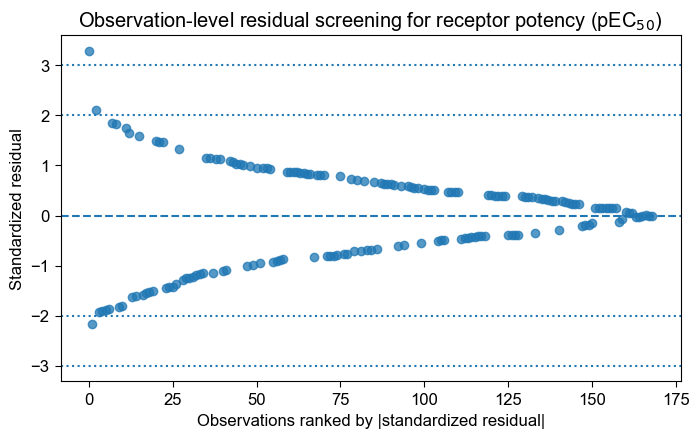


Observation-level influence summary (top suspicious observations):
 original_row_id substance  std_residual  max_abs_change  median_abs_change
               3    104895      1.753755        6.302834           0.078545
              21    104895     -1.815151        6.302834           0.066175
             135 155532408      3.299782        0.124952           0.064449
             124 155532408     -2.172239        0.118752           0.021474
              61    104850      1.849054        0.113425           0.037409
              75    104850     -1.820432        0.091685           0.023734
             111     16078      2.119009        0.054604           0.014423
             147 155541870      1.640307        0.054592           0.013324
             140 155491029     -1.874874        0.048691           0.026205
             100   4402318     -1.635860        0.048265           0.020111
             117     16078     -1.931543        0.039792           0.013891
             114    

In [30]:
# ============================================================
# Observation-level influence diagnostics
# Model A: pEC50_readout_model
# ============================================================

pEC50_readout_obs_influence = observation_influence_pEC50(
    model_dict=pEC50_readout_model,
    top_n=15,
    plot_filename="pEC50_readout_model_observations_ranked.png"
)


===== Observation-level influence: pEC50_membrane_model =====
Top observations by absolute standardized residual:
 original_row_id pubchem_cid   fitted  residual  std_residual
              39      104895 7.823754  2.134853      2.524416
             135   155532408 7.537094  2.015748      2.383577
              69      104850 7.837452 -1.727873     -2.043171
             111       16078 7.047984  1.721567      2.035715
              19      104895 7.823754 -1.636668     -1.935323
              75      104850 7.626531 -1.599659     -1.891561
             117       16078 7.047984 -1.592052     -1.882566
              95     4402318 7.744008 -1.582857     -1.871693
             114       16078 7.047984 -1.566498     -1.852349
              94     4402318 7.230340 -1.509094     -1.784470
              62      104850 7.474849  1.472073      1.740693
              43      104895 7.712545  1.442357      1.705555
              64      104850 7.942704  1.416814      1.675351
              13 

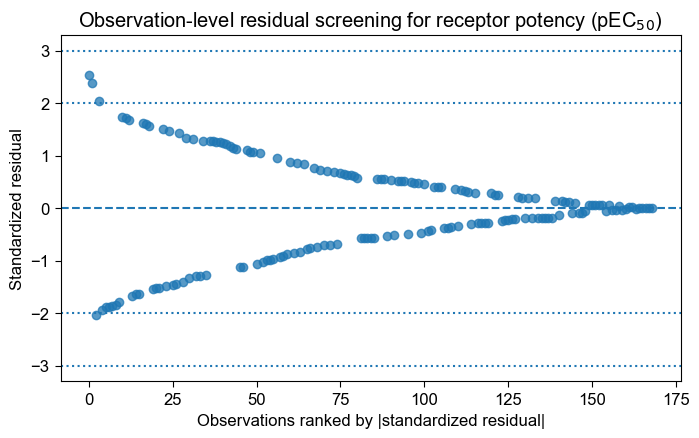


Observation-level influence summary (top suspicious observations):
 original_row_id substance  std_residual  max_abs_change  median_abs_change
              13    104895     -1.669049        7.756816           0.026155
              19    104895     -1.935323        7.756816           0.028904
              43    104895      1.705555        7.756816           0.048288
              39    104895      2.524416        7.756816           0.054612
              69    104850     -2.043171        0.140388           0.013154
             135 155532408      2.383577        0.116246           0.036105
              75    104850     -1.891561        0.103413           0.019824
              64    104850      1.675351        0.094795           0.011201
              62    104850      1.740693        0.073107           0.025795
             128 155532408     -1.632577        0.071881           0.011749
             111     16078      2.035715        0.066523           0.020157
             117    

In [31]:
# ============================================================
# Observation-level influence diagnostics
# Model B: pEC50_membrane_model
# ============================================================

pEC50_membrane_obs_influence = observation_influence_pEC50(
    model_dict=pEC50_membrane_model,
    top_n=15,
    plot_filename="pEC50_membrane_model_observations_ranked.png"
)

## Bilder
### fixed effects bild

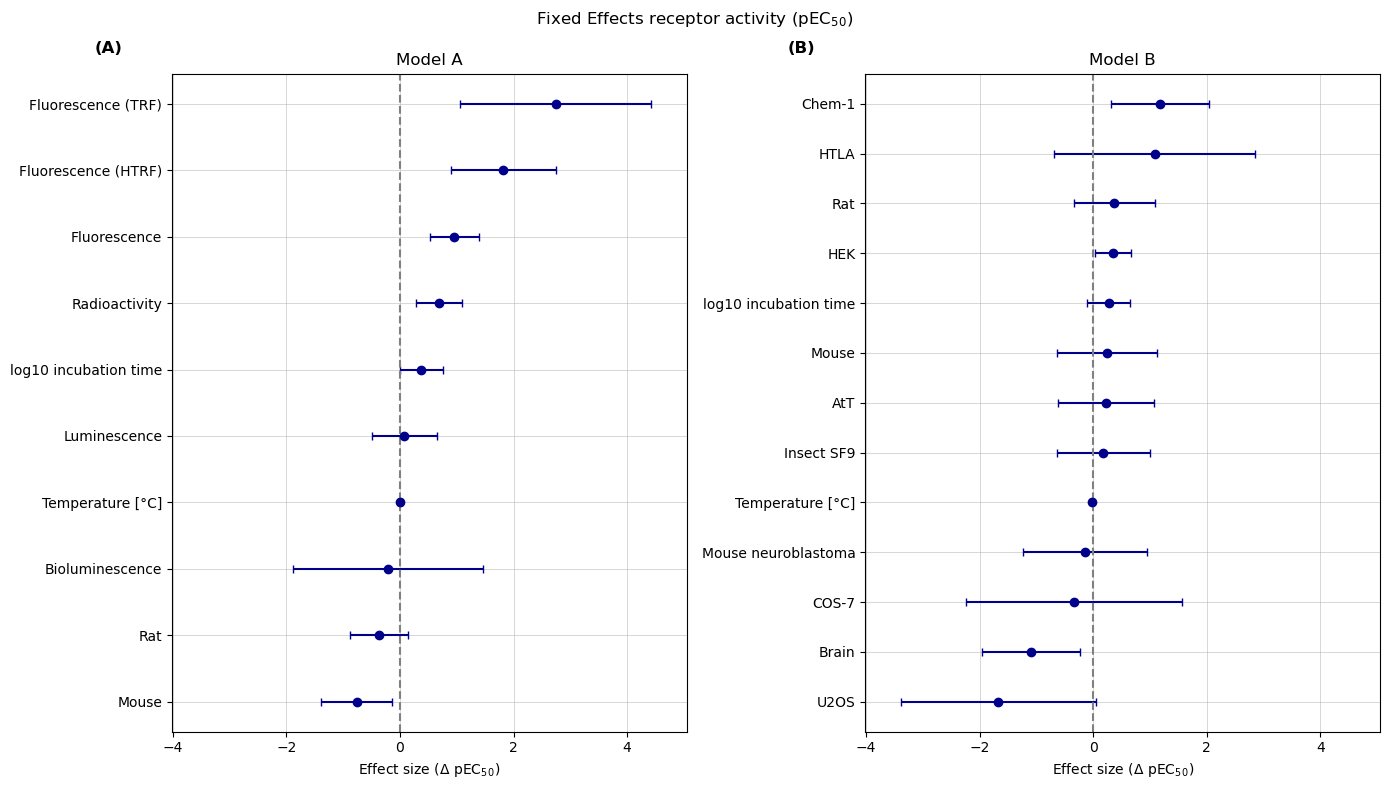

In [32]:
# ============================================================
# Fixed-effects plots for MULTIPLE IMPUTATION pooled results
# pEC50 Model A and Model B
# styled as closely as possible to the pKi fixed-effects plot
# ============================================================


# ------------------------------------------------------------
# 1) helper: raw parameter name -> pretty label for pEC50 models
# ------------------------------------------------------------
def pretty_param_pEC50(name: str) -> str:
    if name == "Intercept":
        return name

    # numeric predictors
    num_map = {
        "log10_incubation_time": "log10 incubation time",
        "temp": "Temperature [°C]",
    }
    if name in num_map:
        return num_map[name]

    # receptor species
    m_species = re.match(
        r"C\(receptor_species, Treatment\(reference='[^']+'\)\)\[T\.(.+)\]", name
    )
    if m_species:
        lvl = m_species.group(1)
        lvl_map = {
            "mouse": "Mouse",
            "rat": "Rat",
            "human": "Human",
        }
        return lvl_map.get(lvl, lvl.replace("_", " "))

    # assay readout
    m_readout = re.match(
        r"C\(assay_readout_clean, Treatment\(reference='[^']+'\)\)\[T\.(.+)\]", name
    )
    if m_readout:
        lvl = m_readout.group(1)
        lvl_map = {
            "bioluminescence": "Bioluminescence",
            "fluorescence": "Fluorescence",
            "fluorescence (HTRF)": "Fluorescence (HTRF)",
            "fluorescence (TRF)": "Fluorescence (TRF)",
            "luminescence": "Luminescence",
            "radioactivity": "Radioactivity",
            "chemiluminescence": "Chemiluminescence",
        }
        return lvl_map.get(lvl, lvl)

    # cell membrane
    m_membrane = re.match(
        r"C\(cell_membrane_clean, Treatment\(reference='[^']+'\)\)\[T\.(.+)\]", name
    )
    if m_membrane:
        lvl = m_membrane.group(1)
        lvl_map = {
            "AtT": "AtT",
            "brain": "Brain",
            "chem-1": "Chem-1",
            "cho": "CHO",
            "cos-7": "COS-7",
            "hek": "HEK",
            "htla": "HTLA",
            "insect-SF9": "Insect SF9",
            "mouse neuroblastoma": "Mouse neuroblastoma",
            "u2os": "U2OS",
        }
        return lvl_map.get(lvl, lvl.replace("_", " "))

    # fallback
    return name.replace("_", " ")


# ------------------------------------------------------------
# 2) helper: prepare pooled df for plotting
# ------------------------------------------------------------
def prepare_fixed_effect_plot_df(pooled_df, drop_intercept=True):
    plot_df = pooled_df[["term", "estimate", "ci_low_95", "ci_high_95"]].copy()

    if drop_intercept:
        plot_df = plot_df[plot_df["term"] != "Intercept"].copy()

    plot_df["label"] = plot_df["term"].apply(pretty_param_pEC50)
    plot_df = plot_df.sort_values("estimate").reset_index(drop=True)

    return plot_df


# ------------------------------------------------------------
# 3) plotting function for pooled MI results
#    same basic style as pKi plot, but in two panels
# ------------------------------------------------------------
def plot_fixed_effects_pEC50_mi(
    pooled_df_A,
    pooled_df_B,
    title="Fixed Effects receptor activity (pEC50)",
    x_label="Effect size (Δ pEC50)",
    outfile="Fixed_effects_pEC50_MI.png",
    drop_intercept=True
):
    # prepare data
    plot_df_A = prepare_fixed_effect_plot_df(pooled_df_A, drop_intercept=drop_intercept)
    plot_df_B = prepare_fixed_effect_plot_df(pooled_df_B, drop_intercept=drop_intercept)

    # common x-axis limits across both panels
    x_min = min(plot_df_A["ci_low_95"].min(), plot_df_B["ci_low_95"].min())
    x_max = max(plot_df_A["ci_high_95"].max(), plot_df_B["ci_high_95"].max())
    x_pad = 0.08 * (x_max - x_min)

    x_min -= x_pad
    x_max += x_pad

    # IMPORTANT: use same simple/default style logic as in pKi
    plt.style.use("default")

    fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharex=True)

    # ---------------- Model A ----------------
    axes[0].errorbar(
        plot_df_A["estimate"],
        plot_df_A["label"],
        xerr=[
            plot_df_A["estimate"] - plot_df_A["ci_low_95"],
            plot_df_A["ci_high_95"] - plot_df_A["estimate"]
        ],
        fmt="o",
        capsize=3,
        color="darkblue",
        ecolor="darkblue"
    )
    axes[0].axvline(0, color="grey", linestyle="--")
    axes[0].set_title("Model A")
    axes[0].text(-0.15, 1.05, "(A)", transform=axes[0].transAxes,
             fontsize=12, fontweight="bold", va="top")
    axes[0].set_xlabel(x_label)
    axes[0].set_xlim(x_min, x_max)

    # ---------------- Model B ----------------
    axes[1].errorbar(
        plot_df_B["estimate"],
        plot_df_B["label"],
        xerr=[
            plot_df_B["estimate"] - plot_df_B["ci_low_95"],
            plot_df_B["ci_high_95"] - plot_df_B["estimate"]
        ],
        fmt="o",
        capsize=3,
        color="darkblue",
        ecolor="darkblue"
    )
    axes[1].axvline(0, color="grey", linestyle="--")
    axes[1].set_title("Model B")
    axes[1].text(-0.15, 1.05, "(B)", transform=axes[1].transAxes,
             fontsize=12, fontweight="bold", va="top")
    axes[1].set_xlabel(x_label)
    axes[1].set_xlim(x_min, x_max)

    fig.suptitle(title)
    for ax in axes:
        ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()

    return plot_df_A, plot_df_B


# ------------------------------------------------------------
# 4) call
# ------------------------------------------------------------
plot_df_A, plot_df_B = plot_fixed_effects_pEC50_mi(
    pooled_df_A=pEC50_readout_model["pooled_fixed"],
    pooled_df_B=pEC50_membrane_model["pooled_fixed"],
    title="Fixed Effects receptor activity (pEC$_5$$_0$)",
    x_label="Effect size (Δ pEC$_5$$_0$)",
    outfile="Fixed_effects_pEC50_MI.png",
    drop_intercept=True
)

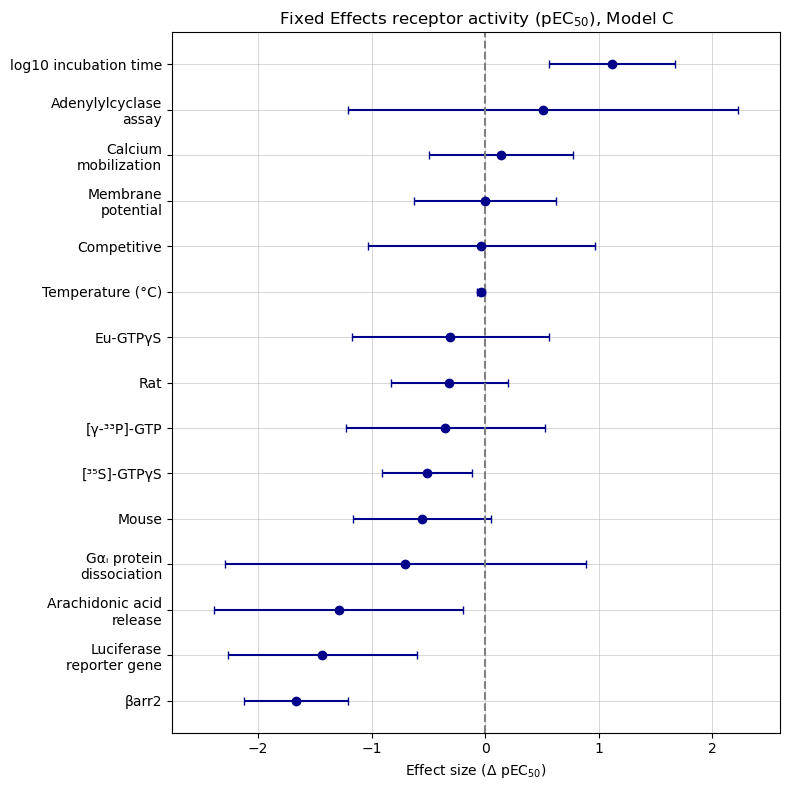

In [33]:
# ============================================================
# Fixed-effects plot for MULTIPLE IMPUTATION pooled results
# pEC50 Model C only
# styled as closely as possible to the pKi fixed-effects plot
# ============================================================


# ------------------------------------------------------------
# 1) helper: normalize labels robustly
# ------------------------------------------------------------
def norm_label(x: str) -> str:
    return re.sub(r"[^0-9A-Za-z]+", "", str(x)).lower()

# ------------------------------------------------------------
# 2) helper: raw parameter name -> pretty label for pEC50 Model C
# ------------------------------------------------------------
def pretty_param_pEC50_modelC(name: str) -> str:
    if name == "Intercept":
        return name

    # numeric predictors
    num_map = {
        "log10_incubation_time": "log10 incubation time",
        "temp": "Temperature (°C)",
    }
    if name in num_map:
        return num_map[name]

    # receptor species
    m_species = re.match(
        r"C\(receptor_species, Treatment\(reference='[^']+'\)\)\[T\.(.+)\]", name
    )
    if m_species:
        lvl = m_species.group(1)
        lvl_map = {
            "mouse": "Mouse",
            "rat": "Rat",
            "human": "Human",
        }
        return lvl_map.get(lvl, lvl.replace("_", " "))

    # assay name / assay type
    m_assay = re.match(
        r"C\(assay_name_clean, Treatment\(reference='[^']+'\)\)\[T\.(.+)\]", name
    )
    if m_assay:
        lvl = m_assay.group(1)

        # robust normalized mapping
        lvl_map_norm = {
            norm_label("cAMP"): "cAMP",
            norm_label("competitive"): "Competitive",
            norm_label("35S_GTP_S"): "[³⁵S]-GTPγS",
            norm_label("35S GTPγS"): "[³⁵S]-GTPγS",
            norm_label("Eu_GTP_S"): "Eu-GTPγS",
            norm_label("Eu GTPγS"): "Eu-GTPγS",
            norm_label("y_33P_GTP"): "[γ-³³P]-GTP",
            norm_label("γ_33P_GTP"): "[γ-³³P]-GTP",
            norm_label("gamma_33P_GTP"): "[γ-³³P]-GTP",
            norm_label("calcium_mobilization"): "Calcium\nmobilization",
            norm_label("membrane_potential"): "Membrane\npotential",
            norm_label("luciferase_reporter_gene_assay"): "Luciferase\nreporter gene",
            norm_label("Adenylylcyclase_assay"): "Adenylylcyclase\nassay",
            norm_label("G_i_protein_dissociation"): "Gαᵢ protein\ndissociation",
            norm_label("Gi_protein_dissociation"): "Gαᵢ protein\ndissociation",
            norm_label("arachidonic_acid_release"): "Arachidonic acid\nrelease",
            norm_label("barr2"): "βarr2",
            norm_label("βarr2"): "βarr2",
        }

        lvl_norm = norm_label(lvl)
        return lvl_map_norm.get(lvl_norm, lvl.replace("_", " "))

    # fallback
    return name.replace("_", " ")


# ------------------------------------------------------------
# 3) helper: prepare pooled df for plotting
# ------------------------------------------------------------
def prepare_fixed_effect_plot_df_modelC(pooled_df, drop_intercept=True):
    plot_df = pooled_df[["term", "estimate", "ci_low_95", "ci_high_95"]].copy()

    if drop_intercept:
        plot_df = plot_df[plot_df["term"] != "Intercept"].copy()

    plot_df["label"] = plot_df["term"].apply(pretty_param_pEC50_modelC)
    plot_df = plot_df.sort_values("estimate").reset_index(drop=True)

    return plot_df


# ------------------------------------------------------------
# 4) plotting function for pooled MI results
# ------------------------------------------------------------
def plot_fixed_effects_pEC50_modelC_mi(
    pooled_df,
    title="Fixed Effects receptor activity (pEC$_{50}$), Model C",
    x_label="Effect size (Δ pEC$_{50}$)",
    outfile="Fixed_effects_pEC50_ModelC_MI.png",
    drop_intercept=True
):
    # prepare data
    plot_df = prepare_fixed_effect_plot_df_modelC(
        pooled_df,
        drop_intercept=drop_intercept
    )

    # x-axis limits with small padding
    x_min = plot_df["ci_low_95"].min()
    x_max = plot_df["ci_high_95"].max()
    x_pad = 0.08 * (x_max - x_min)

    x_min -= x_pad
    x_max += x_pad

    # same simple/default style logic as in pKi
    plt.style.use("default")

    plt.figure(figsize=(8, 8))
    plt.errorbar(
        plot_df["estimate"],
        plot_df["label"],
        xerr=[
            plot_df["estimate"] - plot_df["ci_low_95"],
            plot_df["ci_high_95"] - plot_df["estimate"]
        ],
        fmt="o",
        capsize=3,
        color="darkblue",
        ecolor="darkblue"
    )
    plt.axvline(0, color="grey", linestyle="--")
    plt.title(title)
    plt.xlabel(x_label)
    plt.xlim(x_min, x_max)
    plt.grid(True, linestyle="-", linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()

    return plot_df


# ------------------------------------------------------------
# 5) call
# ------------------------------------------------------------
plot_df_C = plot_fixed_effects_pEC50_modelC_mi(
    pooled_df=pEC50_assayname_model["pooled_fixed"],
    title="Fixed Effects receptor activity (pEC$_{50}$), Model C",
    x_label="Effect size (Δ pEC$_{50}$)",
    outfile="Fixed_effects_pEC50_ModelC_MI.png",
    drop_intercept=True
)

### observed vs. predicted

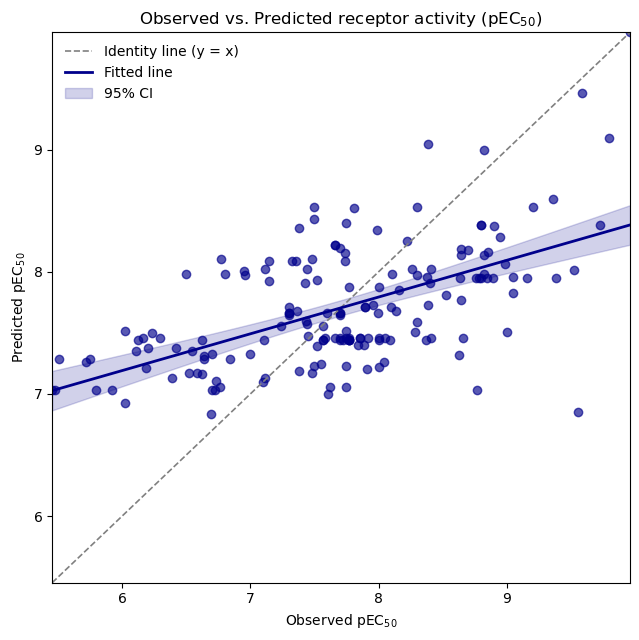

Correlation observed vs predicted: 0.571
RMSE: 0.778
                            OLS Regression Results                            
Dep. Variable:              predicted   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     80.77
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           5.27e-16
Time:                        16:06:11   Log-Likelihood:                -88.953
No. Observations:                 169   AIC:                             181.9
Df Residuals:                     167   BIC:                             188.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [34]:
# ============================================================
# Observed vs Predicted pEC50 for current MI-LMM
# Model A (readout), imputation 1
# - x = observed pEC50
# - y = predicted pEC50
# - includes:
#     1) identity line (y = x)
#     2) fitted regression line
#     3) 95% confidence interval around regression line
# ============================================================


# ------------------------------------------------------------
# 1) take first imputation result directly from Model A
# ------------------------------------------------------------
res_imp_1 = pEC50_readout_model["full_results"][0]

# underlying dataframe used for this fitted model
df_imp_1 = res_imp_1.model.data.frame.copy()

# dependent variable name
y_name = res_imp_1.model.endog_names

# ------------------------------------------------------------
# 2) extract observed and predicted values
# ------------------------------------------------------------
plot_df = pd.DataFrame({
    "observed": df_imp_1[y_name].astype(float).values,
    "predicted": res_imp_1.fittedvalues.astype(float)
}).dropna().copy()

# ------------------------------------------------------------
# 3) regression line + 95% CI
#    predicted ~ observed
# ------------------------------------------------------------
X = sm.add_constant(plot_df["observed"])
ols_line = sm.OLS(plot_df["predicted"], X).fit()

x_grid = np.linspace(plot_df["observed"].min(), plot_df["observed"].max(), 200)
X_grid = sm.add_constant(x_grid)

pred_frame = ols_line.get_prediction(X_grid).summary_frame(alpha=0.05)

# ------------------------------------------------------------
# 4) plotting
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 6.5))

# scatter
ax.scatter(
    plot_df["observed"],
    plot_df["predicted"],
    alpha=0.65,
    color="darkblue"
)

# identity line y = x
xy_min = min(plot_df["observed"].min(), plot_df["predicted"].min())
xy_max = max(plot_df["observed"].max(), plot_df["predicted"].max())

ax.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    linestyle="--",
    color="grey",
    linewidth=1.2,
    label="Identity line (y = x)"
)

# regression line
ax.plot(
    x_grid,
    pred_frame["mean"],
    color="darkblue",
    linewidth=2,
    label="Fitted line"
)

# confidence interval around regression line
ax.fill_between(
    x_grid,
    pred_frame["mean_ci_lower"].values,
    pred_frame["mean_ci_upper"].values,
    color="darkblue",
    alpha=0.18,
    label="95% CI"
)

# labels and title
ax.set_xlabel("Observed pEC$_5$$_0$")
ax.set_ylabel("Predicted pEC$_5$$_0$")
ax.set_title("Observed vs. Predicted receptor activity (pEC$_5$$_0$)")

# equal limits so identity line is meaningful
ax.set_xlim(xy_min, xy_max)
ax.set_ylim(xy_min, xy_max)

ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("Observed_vs_Predicted_pEC50_ModelA_MI_imputation1.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5) optional numeric summary
# ------------------------------------------------------------
corr = np.corrcoef(plot_df["observed"], plot_df["predicted"])[0, 1]
rmse = np.sqrt(np.mean((plot_df["observed"] - plot_df["predicted"])**2))

print(f"Correlation observed vs predicted: {corr:.3f}")
print(f"RMSE: {rmse:.3f}")
print(ols_line.summary())

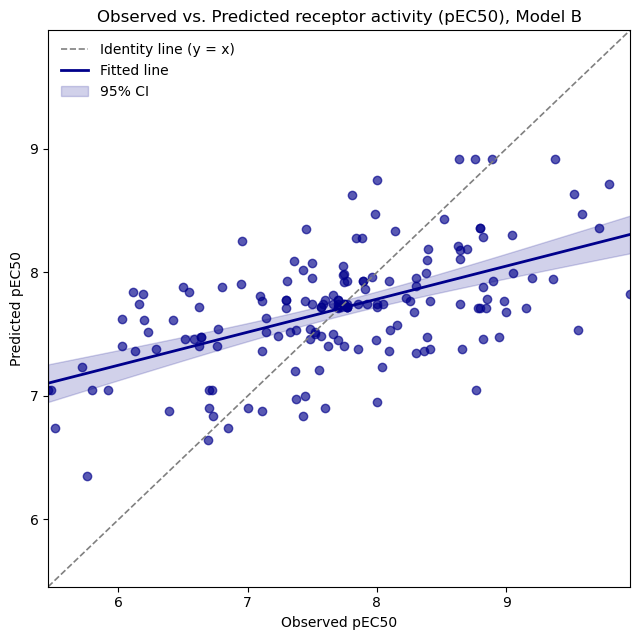

Correlation observed vs predicted: 0.548
RMSE: 0.794
                            OLS Regression Results                            
Dep. Variable:              predicted   R-squared:                       0.300
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     71.52
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           1.32e-14
Time:                        16:06:11   Log-Likelihood:                -79.108
No. Observations:                 169   AIC:                             162.2
Df Residuals:                     167   BIC:                             168.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [35]:
# ============================================================
# Observed vs Predicted pEC50 for current MI-LMM
# Model B (membrane), imputation 1
# - x = observed pEC50
# - y = predicted pEC50
# - includes:
#     1) identity line (y = x)
#     2) fitted regression line
#     3) 95% confidence interval around regression line
# ============================================================


# ------------------------------------------------------------
# 1) take first imputation result directly from Model B
# ------------------------------------------------------------
res_imp_1 = pEC50_membrane_model["full_results"][0]

# underlying dataframe used for this fitted model
df_imp_1 = res_imp_1.model.data.frame.copy()

# dependent variable name
y_name = res_imp_1.model.endog_names

# ------------------------------------------------------------
# 2) extract observed and predicted values
# ------------------------------------------------------------
plot_df = pd.DataFrame({
    "observed": df_imp_1[y_name].astype(float).values,
    "predicted": res_imp_1.fittedvalues.astype(float)
}).dropna().copy()

# ------------------------------------------------------------
# 3) regression line + 95% CI
#    predicted ~ observed
# ------------------------------------------------------------
X = sm.add_constant(plot_df["observed"])
ols_line = sm.OLS(plot_df["predicted"], X).fit()

x_grid = np.linspace(plot_df["observed"].min(), plot_df["observed"].max(), 200)
X_grid = sm.add_constant(x_grid)

pred_frame = ols_line.get_prediction(X_grid).summary_frame(alpha=0.05)

# ------------------------------------------------------------
# 4) plotting
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 6.5))

# scatter
ax.scatter(
    plot_df["observed"],
    plot_df["predicted"],
    alpha=0.65,
    color="darkblue"
)

# identity line y = x
xy_min = min(plot_df["observed"].min(), plot_df["predicted"].min())
xy_max = max(plot_df["observed"].max(), plot_df["predicted"].max())

ax.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    linestyle="--",
    color="grey",
    linewidth=1.2,
    label="Identity line (y = x)"
)

# regression line
ax.plot(
    x_grid,
    pred_frame["mean"],
    color="darkblue",
    linewidth=2,
    label="Fitted line"
)

# confidence interval around regression line
ax.fill_between(
    x_grid,
    pred_frame["mean_ci_lower"].values,
    pred_frame["mean_ci_upper"].values,
    color="darkblue",
    alpha=0.18,
    label="95% CI"
)

# labels and title
ax.set_xlabel("Observed pEC50")
ax.set_ylabel("Predicted pEC50")
ax.set_title("Observed vs. Predicted receptor activity (pEC50), Model B")

# equal limits so identity line is meaningful
ax.set_xlim(xy_min, xy_max)
ax.set_ylim(xy_min, xy_max)

ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("Observed_vs_Predicted_pEC50_ModelB_MI_imputation1.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5) optional numeric summary
# ------------------------------------------------------------
corr = np.corrcoef(plot_df["observed"], plot_df["predicted"])[0, 1]
rmse = np.sqrt(np.mean((plot_df["observed"] - plot_df["predicted"])**2))

print(f"Correlation observed vs predicted: {corr:.3f}")
print(f"RMSE: {rmse:.3f}")
print(ols_line.summary())

# Summary of Dataset

In [36]:
subdatset_df.describe()

,pubchem_cid,value,value_pEC50,incubation_time,temp
count,1.690000e+02,169.000000,169.000000,163.000000,158.000000
mean,3.347977e+07,177.437686,7.704065,110.202454,32.791139
std,6.060743e+07,512.759835,0.948953,195.430639,4.962347
min,1.607800e+04,0.110000,5.455932,1.500000,25.000000
25%,1.048950e+05,4.300000,7.142668,45.000000,30.000000
50%,1.048950e+05,18.200000,7.739929,60.000000,37.000000
75%,1.038270e+07,72.000000,8.366532,90.000000,37.000000
max,1.555419e+08,3500.000000,9.958607,1440.000000,37.000000


In [37]:

print(subdatset_df["assay_name_clean"].value_counts())
print(subdatset_df["assay_sub"].value_counts())
print(subdatset_df["assay_readout_clean"].value_counts())
print(subdatset_df["cell_membrane_clean"].value_counts())
print(subdatset_df["receptor_species"].value_counts())





assay_name_clean
cAMP                              58
[35S]GTPγS                        45
barr2                             23
calcium mobilization               9
membrane potential                 9
luciferase reporter gene assay     7
arachidonic acid release           5
[y-33P]GTP                         4
Eu-GTPγS                           4
competitive                        3
Gαi protein dissociation           1
Adenylylcyclase assay              1
Name: count, dtype: int64
assay_sub
HitHunter                                                42
Lance cAMP kit                                            3
Molecular Devices Membrane Potential Assay Kit (blue)     3
[3H]cAMP                                                  3
barr2                                                     2
Lance ultra cAMP kit                                      2
Cisbio's HTRF HiRange                                     2
BRET                                                      2
stimulated cAMP accumul

### CP55940

In [38]:
CP_df.describe()

,pubchem_cid,value,value_pEC50,incubation_time,temp
count,57.0,57.000000,57.000000,55.000000,51.000000
mean,104895.0,77.578807,7.863229,156.781818,31.078431
std,0.0,155.077543,0.889042,265.569789,5.187844
min,104895.0,0.110000,6.187087,1.500000,25.000000
25%,104895.0,2.330000,7.301030,30.000000,25.000000
50%,104895.0,17.000000,7.769551,60.000000,30.000000
75%,104895.0,50.000000,8.632644,90.000000,37.000000
max,104895.0,650.000000,9.958607,1080.000000,37.000000


In [39]:
print(CP_df["assay_name_clean"].value_counts())
print(CP_df["assay_sub"].value_counts())
print(CP_df["assay_readout_clean"].value_counts())
print(CP_df["cell_membrane_clean"].value_counts())
print(CP_df["receptor_species"].value_counts())


assay_name_clean
[35S]GTPγS                        19
cAMP                              11
barr2                              6
arachidonic acid release           5
luciferase reporter gene assay     5
[y-33P]GTP                         4
calcium mobilization               4
membrane potential                 2
Eu-GTPγS                           1
Name: count, dtype: int64
assay_sub
HitHunter                   3
barr2                       2
Lance ultra cAMP kit        2
CAMYEL BRET                 1
ACTOne                      1
competitive ELISA           1
Lance cAMP kit              1
HTRF cAMP Gs dynamic kit    1
Cisbio's HTRF HiRange       1
Name: count, dtype: int64
assay_readout_clean
radioactivity          28
fluorescence           12
luminescence            8
chemiluminescence       7
fluorescence (TRF)      1
fluorescence (HTRF)     1
Name: count, dtype: int64
cell_membrane_clean
cho                    35
hek                    10
chem-1                  4
insect-SF9        

### Rimonabant

In [40]:
Rimonabant_df.describe()

,pubchem_cid,value,value_pEC50,incubation_time,temp
count,19.0,19.000000,19.000000,18.000000,18.000000
mean,104850.0,130.803000,7.883411,149.722222,32.111111
std,0.0,269.476152,1.092123,338.384885,5.345574
min,104850.0,0.300000,6.026872,25.000000,25.000000
25%,104850.0,1.265000,7.226729,30.000000,26.250000
50%,104850.0,18.000000,7.744727,45.000000,33.500000
75%,104850.0,62.000000,8.900397,82.500000,37.000000
max,104850.0,940.000000,9.522879,1440.000000,37.000000


In [41]:
print(Rimonabant_df["assay_name"].value_counts())
print(Rimonabant_df["assay_sub"].value_counts())
print(Rimonabant_df["assay_readout_clean"].value_counts())
print(Rimonabant_df["cell_membrane_clean"].value_counts())
print(Rimonabant_df["receptor_species"].value_counts())

assay_name
cAMP                        7
barr2                       5
[35S]GTPγS                  4
calcium mobilization        2
Gαi protein dissociation    1
Name: count, dtype: int64
assay_sub
HitHunter                4
BRET                     2
Cisbio's HTRF HiRange    1
Cisbio's HTRF            1
Name: count, dtype: int64
assay_readout_clean
chemiluminescence      9
radioactivity          4
fluorescence           4
bioluminescence        1
fluorescence (HTRF)    1
Name: count, dtype: int64
cell_membrane_clean
cho     10
hek      8
htla     1
Name: count, dtype: int64
receptor_species
human    18
Name: count, dtype: int64


### WIN55212-2

In [42]:
WIN_df.describe()

,pubchem_cid,value,value_pEC50,incubation_time,temp
count,17.0,17.000000,17.000000,17.000000,17.000000
mean,5311501.0,82.258824,7.527634,86.470588,36.176471
std,0.0,180.777723,0.542320,14.552138,2.324739
min,5311501.0,4.300000,6.124939,30.000000,30.000000
25%,5311501.0,17.000000,7.327902,90.000000,37.000000
50%,5311501.0,20.000000,7.698970,90.000000,37.000000
75%,5311501.0,47.000000,7.769551,90.000000,37.000000
max,5311501.0,750.000000,8.366532,90.000000,37.000000


In [43]:
print(WIN_df["assay_name"].value_counts())
print(WIN_df["assay_sub"].value_counts())
print(WIN_df["assay_readout_clean"].value_counts())
print(WIN_df["cell_membrane_clean"].value_counts())
print(WIN_df["receptor_species"].value_counts())

assay_name
cAMP          14
[35S]GTPγS     2
barr2          1
Name: count, dtype: int64
assay_sub
HitHunter    14
Name: count, dtype: int64
assay_readout_clean
chemiluminescence    15
radioactivity         2
Name: count, dtype: int64
cell_membrane_clean
hek    10
cho     7
Name: count, dtype: int64
receptor_species
human    17
Name: count, dtype: int64


### CHEMBL4450922

In [44]:
CHEMBL4450922_df.describe()

,pubchem_cid,value,value_pEC50,incubation_time,temp
count,18.0,18.000000,18.000000,18.000000,18.000000
mean,4402318.0,193.344444,7.536862,83.333333,36.222222
std,0.0,466.923884,0.788242,19.402850,2.263666
min,4402318.0,2.200000,5.721246,30.000000,30.000000
25%,4402318.0,10.500000,7.507371,90.000000,37.000000
50%,4402318.0,17.500000,7.757139,90.000000,37.000000
75%,4402318.0,31.250000,7.980205,90.000000,37.000000
max,4402318.0,1900.000000,8.657577,90.000000,37.000000


In [45]:
print(CHEMBL4450922_df["assay_name"].value_counts())
print(CHEMBL4450922_df["assay_sub"].value_counts())
print(CHEMBL4450922_df["assay_readout_clean"].value_counts())
print(CHEMBL4450922_df["cell_membrane_clean"].value_counts())
print(CHEMBL4450922_df["receptor_species"].value_counts())

assay_name
cAMP          15
[35S]GTPγS     2
barr2          1
Name: count, dtype: int64
assay_sub
HitHunter    15
Name: count, dtype: int64
assay_readout_clean
chemiluminescence    16
radioactivity         2
Name: count, dtype: int64
cell_membrane_clean
hek    10
cho     8
Name: count, dtype: int64
receptor_species
human    18
Name: count, dtype: int64


### delta-9-THC

In [46]:
THC9_df.describe()

,pubchem_cid,value,value_pEC50,incubation_time,temp
count,13.0,13.000000,13.000000,13.000000,13.000000
mean,16078.0,789.446154,6.978971,71.538462,35.692308
std,0.0,1263.151638,1.104966,24.612380,3.250247
min,16078.0,1.700000,5.455932,30.000000,27.000000
25%,16078.0,18.000000,5.920819,45.000000,37.000000
50%,16078.0,172.000000,6.764472,90.000000,37.000000
75%,16078.0,1200.000000,7.744727,90.000000,37.000000
max,16078.0,3500.000000,8.769551,90.000000,37.000000


In [47]:
print(THC9_df["assay_name"].value_counts())
print(THC9_df["assay_sub"].value_counts())
print(THC9_df["assay_readout_clean"].value_counts())
print(THC9_df["cell_membrane_clean"].value_counts())
print(THC9_df["receptor_species"].value_counts())

assay_name
barr2                   6
membrane potential      3
cAMP                    2
[35S]GTPγS              1
calcium mobilization    1
Name: count, dtype: int64
assay_sub
Molecular Devices Membrane Potential Assay Kit (blue)    3
HitHunter                                                1
Cisbio's HTRF dynamic cAMP kit                           1
Name: count, dtype: int64
assay_readout_clean
chemiluminescence    7
fluorescence         5
radioactivity        1
Name: count, dtype: int64
cell_membrane_clean
cho    9
AtT    3
hek    1
Name: count, dtype: int64
receptor_species
human    10
mouse     3
Name: count, dtype: int64


### CHEMBL4467516

In [48]:
CHEMBL4467516_df.describe()

,pubchem_cid,value,value_pEC50,incubation_time,temp
count,12.0,12.000000,12.000000,10.000000,10.000000
mean,155532408.0,418.994167,7.107258,58.000000,31.800000
std,0.0,877.506600,1.023757,20.165978,4.871687
min,155532408.0,0.280000,5.510604,25.000000,25.000000
25%,155532408.0,29.265000,6.677345,45.000000,30.000000
50%,155532408.0,121.500000,6.922332,60.000000,30.000000
75%,155532408.0,210.500000,7.534101,60.000000,37.000000
max,155532408.0,3086.000000,9.552842,90.000000,37.000000


In [49]:
print(CHEMBL4467516_df["assay_name"].value_counts())
print(CHEMBL4467516_df["assay_sub"].value_counts())
print(CHEMBL4467516_df["assay_readout_clean"].value_counts())
print(CHEMBL4467516_df["cell_membrane_clean"].value_counts())
print(CHEMBL4467516_df["receptor_species"].value_counts())

assay_name
[35S]GTPγS              6
cAMP                    2
membrane potential      2
calcium mobilization    1
barr2                   1
Name: count, dtype: int64
assay_sub
HitHunter                       1
stimulated cAMP accumulation    1
Name: count, dtype: int64
assay_readout_clean
radioactivity        6
fluorescence         3
chemiluminescence    3
Name: count, dtype: int64
cell_membrane_clean
brain                  5
cho                    4
mouse neuroblastoma    2
hek                    1
Name: count, dtype: int64
receptor_species
rat      6
human    4
mouse    1
Name: count, dtype: int64


### CHEMBL4519310

In [50]:
CHEMBL4519310_df.describe()

,pubchem_cid,value,value_pEC50,incubation_time,temp
count,11.0,11.000000,11.000000,11.000000,10.000000
mean,155541870.0,8.190000,8.592513,41.818182,30.600000
std,0.0,11.023568,0.829494,21.362669,4.926121
min,155541870.0,0.160000,7.431798,10.000000,25.000000
25%,155541870.0,0.930000,7.972885,20.000000,26.250000
50%,155541870.0,2.280000,8.642065,60.000000,30.000000
75%,155541870.0,10.650000,9.190453,60.000000,35.250000
max,155541870.0,37.000000,9.795880,60.000000,37.000000


In [51]:
print(CHEMBL4519310_df["assay_name"].value_counts())
print(CHEMBL4519310_df["assay_sub"].value_counts())
print(CHEMBL4519310_df["assay_readout_clean"].value_counts())
print(CHEMBL4519310_df["cell_membrane_clean"].value_counts())
print(CHEMBL4519310_df["receptor_species"].value_counts())

assay_name
cAMP                     4
[35S]GTPγS               4
Eu-GTPγS                 1
Adenylylcyclase assay    1
competitive cAMP         1
Name: count, dtype: int64
assay_sub
Lance cAMP kit    2
HitHunter         2
[3H]cAMP          2
Name: count, dtype: int64
assay_readout_clean
radioactivity          6
fluorescence (HTRF)    2
luminescence           2
fluorescence           1
Name: count, dtype: int64
cell_membrane_clean
cho      7
hek      1
cos-7    1
Name: count, dtype: int64
receptor_species
human    8
rat      3
Name: count, dtype: int64


### CHEMBL4549068

In [52]:
CHEMBL4549068_df.describe()

,pubchem_cid,value,value_pEC50,incubation_time,temp
count,9.0,9.000000,9.000000,8.000000,9.000000
mean,155491029.0,217.062222,7.794326,42.500000,29.333333
std,0.0,579.648611,0.987687,16.475089,4.924429
min,155491029.0,1.500000,5.754487,20.000000,25.000000
25%,155491029.0,2.280000,7.376751,28.750000,25.000000
50%,155491029.0,12.300000,7.910095,42.500000,30.000000
75%,155491029.0,42.000000,8.642065,60.000000,30.000000
max,155491029.0,1760.000000,8.823909,60.000000,37.000000


In [53]:
print(CHEMBL4549068_df["assay_name"].value_counts())
print(CHEMBL4549068_df["assay_sub"].value_counts())
print(CHEMBL4549068_df["assay_readout_clean"].value_counts())
print(CHEMBL4549068_df["cell_membrane_clean"].value_counts())
print(CHEMBL4549068_df["receptor_species"].value_counts())

assay_name
[35S]GTPγS          4
Eu-GTPγS            2
cAMP                1
competitive cAMP    1
barr2               1
Name: count, dtype: int64
assay_sub
stimulated cAMP accumulation    1
[3H]cAMP                        1
Name: count, dtype: int64
assay_readout_clean
radioactivity        5
chemiluminescence    2
fluorescence         2
Name: count, dtype: int64
cell_membrane_clean
hek           4
cho           2
brain         1
u2os          1
insect-SF9    1
Name: count, dtype: int64
receptor_species
human    7
mouse    1
Name: count, dtype: int64


### JWH-018

In [54]:
JWH018_df.describe()

,pubchem_cid,value,value_pEC50,incubation_time,temp
count,7.0,7.000000,7.000000,7.000000,6.000000
mean,10382701.0,46.005714,7.671890,135.000000,33.833333
std,0.0,63.965337,0.619412,115.217186,5.154286
min,10382701.0,2.360000,6.730464,45.000000,25.000000
25%,10382701.0,12.975000,7.362401,60.000000,31.750000
50%,10382701.0,20.000000,7.698970,60.000000,37.000000
75%,10382701.0,43.860000,7.960953,210.000000,37.000000
max,10382701.0,186.010000,8.627088,300.000000,37.000000


In [55]:
print(JWH018_df["assay_name"].value_counts())
print(JWH018_df["assay_sub"].value_counts())
print(JWH018_df["assay_readout_clean"].value_counts())
print(JWH018_df["cell_membrane_clean"].value_counts())
print(JWH018_df["receptor_species"].value_counts())

assay_name
luciferase reporter gene assay    2
competitive                       1
[35S]GTPγS                        1
calcium mobilization              1
membrane potential                1
barr2                             1
Name: count, dtype: int64
Series([], Name: count, dtype: int64)
assay_readout_clean
radioactivity        2
luminescence         2
fluorescence         2
chemiluminescence    1
Name: count, dtype: int64
cell_membrane_clean
cho      3
hek      2
brain    1
AtT      1
Name: count, dtype: int64
receptor_species
human    6
mouse    1
Name: count, dtype: int64


### ZCZ011

In [56]:
ZCZ011_df.describe()

,pubchem_cid,value,value_pEC50,incubation_time,temp
count,6.0,6.000000,6.000000,6.000000,6.000000
mean,71819307.0,90.783333,7.663557,70.000000,32.666667
std,0.0,157.832575,0.910988,36.331804,5.085928
min,71819307.0,1.000000,6.389340,30.000000,25.000000
25%,71819307.0,8.400000,7.197575,37.500000,30.000000
50%,71819307.0,26.750000,7.597250,75.000000,33.500000
75%,71819307.0,66.625000,8.149179,90.000000,37.000000
max,71819307.0,408.000000,9.000000,120.000000,37.000000


In [57]:
print(ZCZ011_df["assay_name"].value_counts())
print(ZCZ011_df["assay_sub"].value_counts())
print(ZCZ011_df["assay_readout_clean"].value_counts())
print(ZCZ011_df["cell_membrane_clean"].value_counts())
print(ZCZ011_df["receptor_species"].value_counts())

assay_name
[35S]GTPγS            2
cAMP                  2
membrane potential    1
barr2                 1
Name: count, dtype: int64
assay_sub
HitHunter    2
Name: count, dtype: int64
assay_readout_clean
chemiluminescence    3
radioactivity        2
fluorescence         1
Name: count, dtype: int64
cell_membrane_clean
brain    2
cho      2
AtT      1
hek      1
Name: count, dtype: int64
receptor_species
human    4
mouse    2
Name: count, dtype: int64
